In [3]:
pip install pandoc

In [1056]:
import pandas as pd
import numpy as np
from scipy.stats import shapiro, zscore
from sklearn.svm import SVC, LinearSVC, SVR
from sklearn.feature_selection import SequentialFeatureSelector, SelectKBest, chi2
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report, confusion_matrix,
    precision_recall_curve, mean_absolute_error, mean_squared_error, r2_score, log_loss, silhouette_score
)
import keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, BatchNormalization, Reshape, Flatten
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from mpl_toolkits.mplot3d import Axes3D
from scipy.cluster.hierarchy import dendrogram, linkage


The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [710]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')


In [914]:

data=pd.read_csv("Ml Tutorials/2022QUB (1).csv")

In [811]:
data.head()

,SID,Type,Matrix,Load,I001,I002,I003,I004,I005,I006,...,I503,I504,I505,I506,I507,I508,I509,I510,I511,I512
0,S1,X,dmem,1,97.78,97.73,97.68,97.70,97.73,97.73,...,83.38,84.49,84.94,85.47,86.16,86.79,87.12,87.20,87.58,88.20
1,S1,X,dmem,1,97.75,97.70,97.70,97.71,97.71,97.72,...,83.65,84.77,85.34,85.27,85.69,85.52,85.27,85.28,85.41,85.65
2,S1,X,dmem,1,97.76,97.72,97.70,97.74,97.71,97.71,...,84.46,85.38,86.03,86.38,86.77,87.10,87.14,86.89,87.14,87.79
3,S1,X,dmem,1,97.72,97.71,97.71,97.73,97.70,97.71,...,83.96,84.89,85.43,85.30,85.80,86.18,86.39,86.63,87.21,87.76
4,S1,X,dmem,1,97.74,97.66,97.65,97.68,97.67,97.65,...,83.65,84.02,84.33,84.53,85.14,85.40,85.41,85.42,85.88,85.87


In [812]:
data.shape

(3801, 516)

## 1. Regression Approach
Build a regression model to quantify the viral load. sues.


### Objective: 
Quantify viral load as a continuous variable.


In [822]:
#i0n this regression task we will be pedicting Load feature
#Load is target feature

In [824]:
data.describe()

,Load,I001,I002,I003,I004,I005,I006,I007,I008,I009,...,I503,I504,I505,I506,I507,I508,I509,I510,I511,I512
count,3801.000000,3801.00000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,...,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000
mean,4.015259,94.65562,94.645662,94.640797,94.629976,94.617727,94.609816,94.577929,94.550316,94.531181,...,85.624488,86.004936,86.365491,86.747143,87.125264,87.331589,87.534875,87.741886,87.914770,88.071718
std,2.067487,2.57733,2.584697,2.584932,2.591785,2.593300,2.588944,2.585280,2.575187,2.572254,...,2.130029,2.181635,2.215189,2.232610,2.246044,2.286217,2.299715,2.304504,2.331248,2.379595
min,1.000000,80.95000,80.890000,80.830000,80.800000,80.760000,80.840000,80.910000,80.890000,80.830000,...,71.640000,71.950000,72.190000,72.550000,73.030000,73.210000,73.290000,73.240000,73.110000,72.940000
25%,2.000000,92.87000,92.870000,92.860000,92.820000,92.800000,92.760000,92.740000,92.750000,92.740000,...,84.500000,84.830000,85.180000,85.590000,85.940000,86.120000,86.290000,86.450000,86.570000,86.700000
50%,4.000000,94.53000,94.510000,94.520000,94.510000,94.480000,94.490000,94.440000,94.430000,94.410000,...,86.000000,86.430000,86.760000,87.110000,87.490000,87.670000,87.840000,88.020000,88.180000,88.300000
75%,6.000000,96.07000,96.040000,96.030000,96.030000,96.020000,96.030000,96.010000,95.970000,95.940000,...,87.070000,87.530000,87.900000,88.260000,88.640000,88.900000,89.170000,89.380000,89.570000,89.730000
max,8.000000,100.71000,100.620000,100.550000,100.540000,100.540000,100.440000,100.310000,100.230000,100.220000,...,90.100000,90.810000,91.300000,91.650000,91.900000,92.090000,92.410000,92.600000,92.960000,93.580000



### Data Preprocessing: 
Address missing values, normalize spectral data if necessary, and split data into training, validation, and testing sets.


In [950]:
data_c=data.copy()

In [951]:

missing_values = data.isnull().sum()

# Show columns with missing values
missing_columns = missing_values[missing_values > 0]

In [952]:
missing_columns.head()

Series([], dtype: int64)

Seems there are no missing values. 
Doing Quick view of distinct categorical values to see if there are any Blanks (''), 'NA' etc values

In [954]:
categorical_features=data.select_dtypes(include=['object']).columns.tolist()

In [955]:
categorical_features

['SID', 'Type', 'Matrix']

Seeing distinct values of categorical columns and their counts

In [962]:
for column in categorical_features:
    print(data[column].value_counts())

SID
S4    1150
S2    1100
S3    1100
S1     451
Name: count, dtype: int64
Type
Y    2281
X    1520
Name: count, dtype: int64
Matrix
pbs     1970
dmem    1831
Name: count, dtype: int64


#### One-Hot Encoding

In [965]:
#no NA's as such or empty vaalues
#Not a lot of categories, most of these features seem not ordinal and binary, so can convert yes no features to 1,0 as 1'st step- 

In [967]:
## removing whitestrip or spaces in front of letters
for column in categorical_features:
    data[column] = data[column].str.strip()


Not a lot of categories, most of these features seem non ordinal and binary, so can convert features with two disctnct values as o or 1;Other  non ordinal features with multiple categories with one hot encoding  

In [970]:
binary_map = {'X': 1, 'Y': 0}
data['Type']=data['Type'].map(binary_map)

In [972]:
#renmaing column to make sense
data=data.rename(columns={"Type": "TypeX"})


In [974]:
binary_map = {'pbs': 1, 'dmem': 0}
data['Matrix']=data['Matrix'].map(binary_map)
data=data.rename(columns={"Matrix": "MatrixPbs"})


In [976]:
data = pd.get_dummies(data, columns=['SID'], drop_first=True)

In [978]:
data.head()

,TypeX,MatrixPbs,Load,I001,I002,I003,I004,I005,I006,I007,...,I506,I507,I508,I509,I510,I511,I512,SID_S2,SID_S3,SID_S4
0,1,0,1,97.78,97.73,97.68,97.70,97.73,97.73,97.72,...,85.47,86.16,86.79,87.12,87.20,87.58,88.20,False,False,False
1,1,0,1,97.75,97.70,97.70,97.71,97.71,97.72,97.74,...,85.27,85.69,85.52,85.27,85.28,85.41,85.65,False,False,False
2,1,0,1,97.76,97.72,97.70,97.74,97.71,97.71,97.74,...,86.38,86.77,87.10,87.14,86.89,87.14,87.79,False,False,False
3,1,0,1,97.72,97.71,97.71,97.73,97.70,97.71,97.70,...,85.30,85.80,86.18,86.39,86.63,87.21,87.76,False,False,False
4,1,0,1,97.74,97.66,97.65,97.68,97.67,97.65,97.69,...,84.53,85.14,85.40,85.41,85.42,85.88,85.87,False,False,False


In [981]:
data.describe()

,TypeX,MatrixPbs,Load,I001,I002,I003,I004,I005,I006,I007,...,I503,I504,I505,I506,I507,I508,I509,I510,I511,I512
count,3801.000000,3801.000000,3801.000000,3801.00000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,...,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000,3801.000000
mean,0.399895,0.518285,4.015259,94.65562,94.645662,94.640797,94.629976,94.617727,94.609816,94.577929,...,85.624488,86.004936,86.365491,86.747143,87.125264,87.331589,87.534875,87.741886,87.914770,88.071718
std,0.489941,0.499731,2.067487,2.57733,2.584697,2.584932,2.591785,2.593300,2.588944,2.585280,...,2.130029,2.181635,2.215189,2.232610,2.246044,2.286217,2.299715,2.304504,2.331248,2.379595
min,0.000000,0.000000,1.000000,80.95000,80.890000,80.830000,80.800000,80.760000,80.840000,80.910000,...,71.640000,71.950000,72.190000,72.550000,73.030000,73.210000,73.290000,73.240000,73.110000,72.940000
25%,0.000000,0.000000,2.000000,92.87000,92.870000,92.860000,92.820000,92.800000,92.760000,92.740000,...,84.500000,84.830000,85.180000,85.590000,85.940000,86.120000,86.290000,86.450000,86.570000,86.700000
50%,0.000000,1.000000,4.000000,94.53000,94.510000,94.520000,94.510000,94.480000,94.490000,94.440000,...,86.000000,86.430000,86.760000,87.110000,87.490000,87.670000,87.840000,88.020000,88.180000,88.300000
75%,1.000000,1.000000,6.000000,96.07000,96.040000,96.030000,96.030000,96.020000,96.030000,96.010000,...,87.070000,87.530000,87.900000,88.260000,88.640000,88.900000,89.170000,89.380000,89.570000,89.730000
max,1.000000,1.000000,8.000000,100.71000,100.620000,100.550000,100.540000,100.540000,100.440000,100.310000,...,90.100000,90.810000,91.300000,91.650000,91.900000,92.090000,92.410000,92.600000,92.960000,93.580000


In [983]:

X = data.drop(columns=['Load'])  # Replace 'load' with the actual target column name
y = data['Load']


In [985]:
#Doing a split of 70% train, 15% test, 15% validation

In [989]:
# stratify on Load

In [990]:
# Split the data into train (70%) and test (30%), stratified on 'Viral_Load'
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Further split the test set into validation (50%) and test (50%), stratified on 'Viral_Load'
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)


In [993]:
X_train.shape

(2660, 517)

In [995]:
y_train.shape

(2660,)

#### All other features than the I001-i512 have just two values..We need  to normalization for features 1001 to 1512 as the rangge is quite high in those, and output

In [999]:


normality_results = {}
for column in X_train.columns:
    stat, p_value = shapiro(X_train[column])
    normality_results[column] = p_value
    if p_value > 0.05:
        print(f"{column} is likely normally distributed (p-value: {p_value})")


In [865]:
columnsLightWavelengths = [col for col in data.columns if col.startswith('I')]


as not normally distributed going with MinMax Scaler

In [876]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train.loc[:, columnsLightWavelengths] = scaler.fit_transform(X_train[columnsLightWavelengths])
X_val.loc[:, columnsLightWavelengths] = scaler.transform(X_val[columnsLightWavelengths])
X_test.loc[:, columnsLightWavelengths]= scaler.transform(X_test[columnsLightWavelengths])

In [878]:
X_train.describe()

,TypeX,MatrixPbs,I001,I002,I003,I004,I005,I006,I007,I008,...,I503,I504,I505,I506,I507,I508,I509,I510,I511,I512
count,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,...,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000,2660.000000
mean,0.401128,0.516165,0.692269,0.695870,0.699010,0.699223,0.699149,0.701073,0.703026,0.704835,...,0.755993,0.749333,0.739521,0.741978,0.745795,0.746700,0.743717,0.747934,0.744858,0.747682
std,0.490219,0.499833,0.131330,0.131894,0.131991,0.132195,0.131993,0.132990,0.134173,0.134089,...,0.116362,0.117416,0.117104,0.117605,0.119826,0.121892,0.121055,0.119895,0.118150,0.118411
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.602733,0.607197,0.610041,0.608789,0.608569,0.608163,0.609665,0.612978,...,0.695016,0.685230,0.678046,0.682723,0.683625,0.683263,0.679786,0.681818,0.678086,0.680514
50%,0.000000,1.000000,0.685729,0.689052,0.692698,0.693516,0.692619,0.695153,0.696392,0.698552,...,0.776815,0.771902,0.761029,0.760209,0.765766,0.764301,0.759414,0.762397,0.757683,0.758902
75%,1.000000,1.000000,0.761134,0.764318,0.768763,0.769504,0.769590,0.772449,0.776289,0.778309,...,0.834778,0.830796,0.819328,0.820942,0.825649,0.829979,0.829629,0.832128,0.827708,0.829871
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [880]:
X_train.shape

(2660, 517)

In [894]:

result = data_c[['Type', 'SID']].value_counts().reset_index(name='count')

sorted_result = result.sort_values(by=['Type', 'SID'], ascending=[True, True])
sorted_result

,Type,SID,count
6,X,S1,320
3,X,S2,400
4,X,S3,400
5,X,S4,400
7,Y,S1,131
1,Y,S2,700
2,Y,S3,700
0,Y,S4,750



### Feature Engineering: 
Evaluate spectral data's key features using techniques like PCA to reduce dimensionality without losing essential variance.


#### EDA

In [798]:
summary_stats = data_c.groupby(['SID'])['Load'].agg(
    mean=lambda x: x.mean(),
    median=lambda x: x.median(),
    std=lambda x: x.std()
).reset_index()

print(summary_stats)

  SID      mean  median       std
0  S1  3.463415     3.0  1.772723
1  S2  4.090909     4.0  2.109580
2  S3  4.090909     4.0  2.109580
3  S4  4.086957     4.0  2.063252


In [786]:
summary_stats = data_c.groupby(['Type'])['Load'].agg(
    mean=lambda x: x.mean(),
    median=lambda x: x.median(),
    std=lambda x: x.std()
).reset_index()

print(summary_stats)

  Type      mean  median       std
0    X  2.552632     3.0  1.117162
1    Y  4.989917     5.0  1.978921


In [53]:
summary_stats = data_c.groupby(['Matrix'])['Load'].agg(
    mean=lambda x: x.mean(),
    median=lambda x: x.median(),
    std=lambda x: x.std()
).reset_index()

print(summary_stats)

  Matrix      mean  median       std
0   dmem  4.075369     4.0  2.068974
1    pbs  3.959391     4.0  2.065061


In [54]:
data_train= pd.concat([X_train, y_train], axis=1)


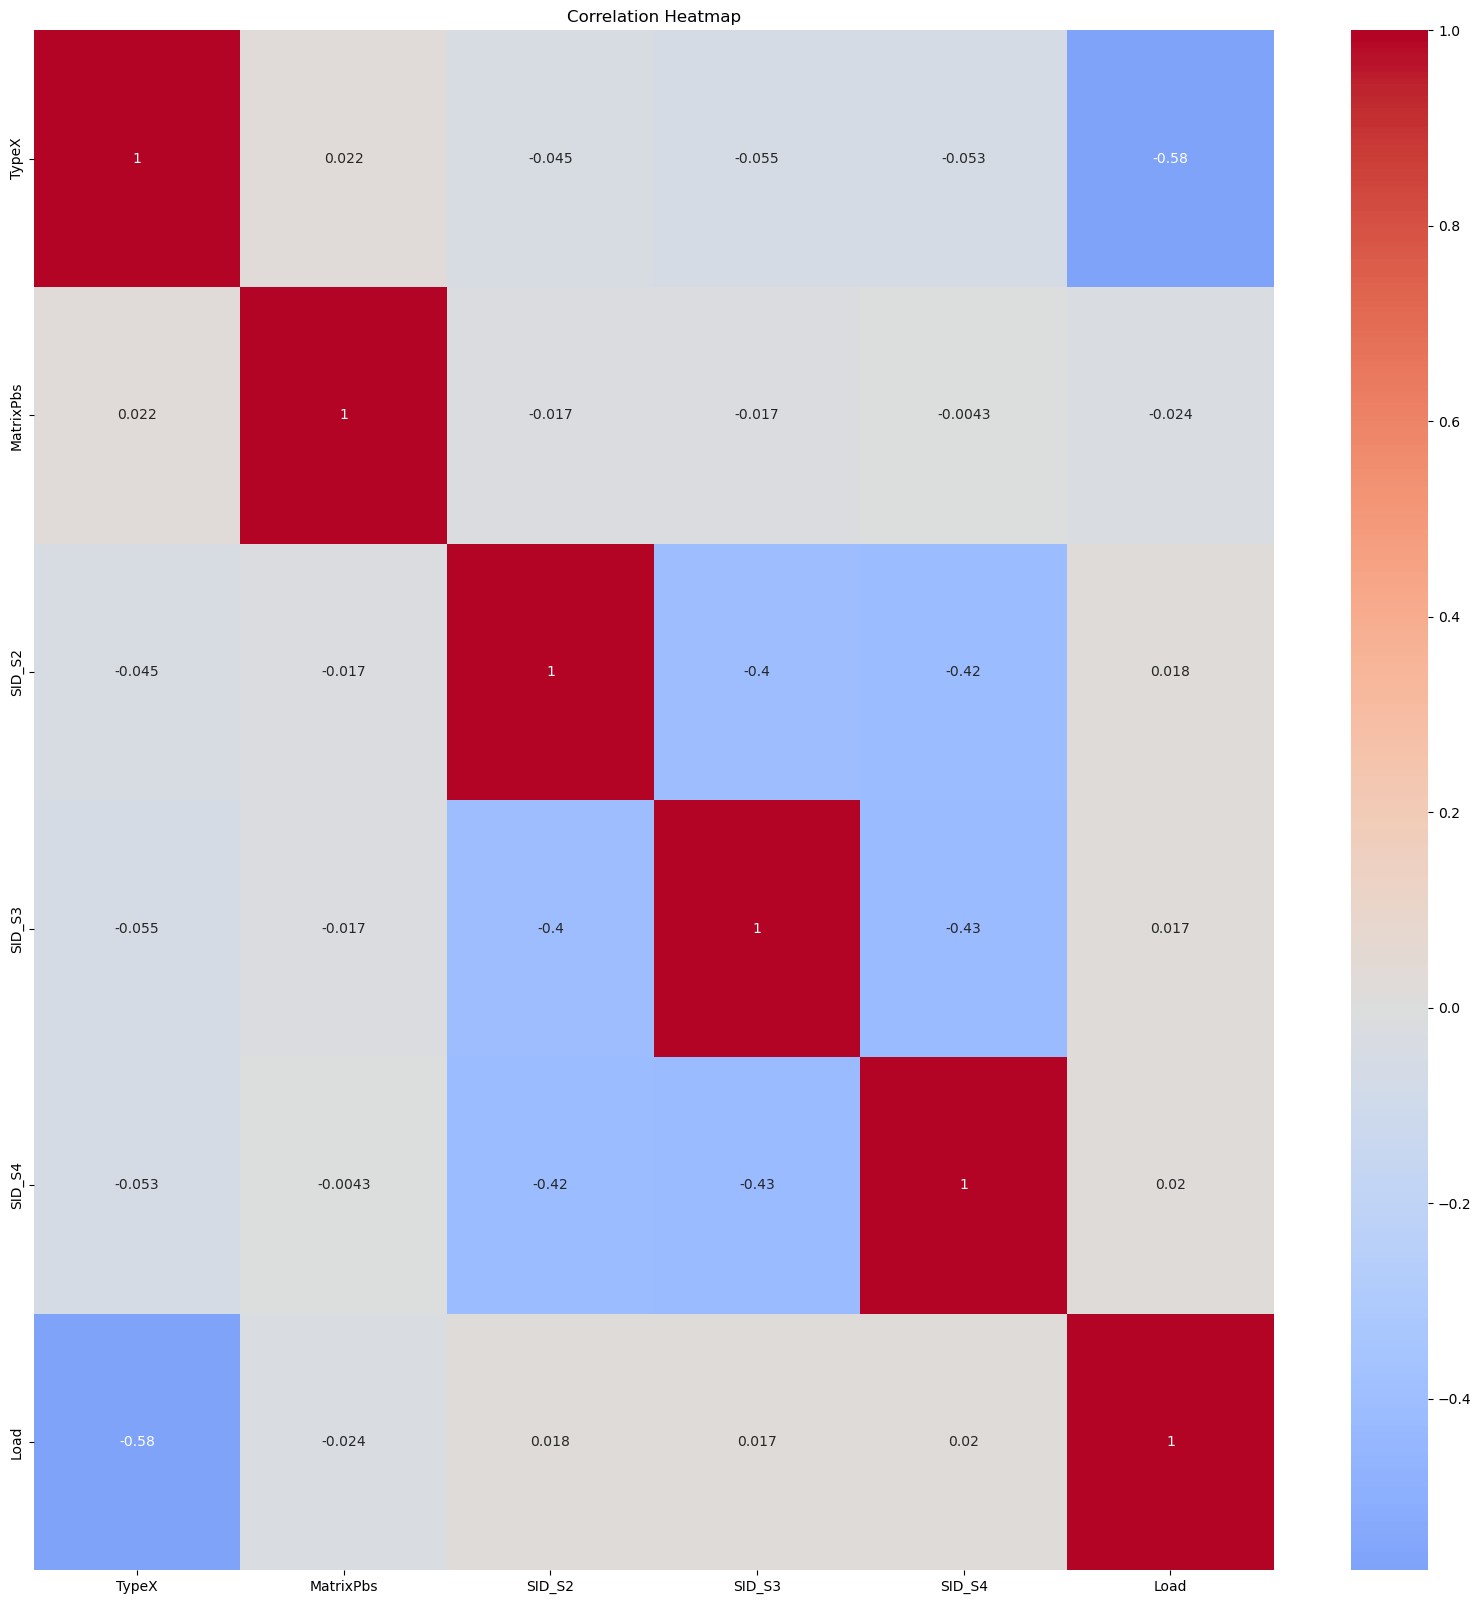

In [55]:


correlation_matrix = data_train[['TypeX',	'MatrixPbs','SID_S2',	'SID_S3',	'SID_S4' ,'Load']].corr()

plt.figure(figsize=(20,20))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [56]:
pd.set_option('display.max_rows', None)
correlation_matrix = data_train.corr()

correlation_flat = correlation_matrix.abs().unstack().sort_values(ascending=False)['Load']

correlation_flat = correlation_flat[correlation_flat != 1]

correlation_flat


TypeX        0.575427
I002         0.183597
I004         0.183179
I003         0.183017
I001         0.181755
I005         0.181556
I006         0.180061
I007         0.179230
I008         0.177943
I009         0.175698
I027         0.175232
I024         0.174828
I028         0.174680
I023         0.174615
I025         0.174094
I026         0.174003
I022         0.173904
I010         0.173601
I029         0.173507
I030         0.173224
I021         0.173126
I020         0.172671
I099         0.172650
I100         0.172427
I079         0.172315
I080         0.172306
I078         0.172216
I101         0.171996
I011         0.171871
I031         0.171827
I098         0.171621
I077         0.171513
I081         0.171416
I075         0.171358
I074         0.171313
I076         0.171218
I102         0.170823
I084         0.170823
I032         0.170699
I083         0.170640
I073         0.170620
I085         0.170529
I082         0.170493
I097         0.170458
I072         0.170216
I061      

In [57]:
pd.reset_option('display.max_rows')


In [58]:
correlation_matrix = data_train[columnsLightWavelengths].corr()

correlation_flat = correlation_matrix.abs().unstack().sort_values(ascending=False)

# Remove self-correlations (correlation of a column with itself) from the result
correlation_flat = correlation_flat[correlation_flat != 1]

correlation_flat

I341  I342    9.999926e-01
I342  I341    9.999926e-01
I345  I346    9.999918e-01
I346  I345    9.999918e-01
I335  I336    9.999916e-01
                  ...     
I408  I149    1.352761e-05
I224  I323    1.882111e-06
I323  I224    1.882111e-06
I155  I380    8.902052e-07
I380  I155    8.902052e-07
Length: 261632, dtype: float64

Seems like light intensities at consecutive wavelengths are highly correlated.. Binning might be a good option here or PCA

In [60]:
pd.set_option('display.max_rows', None)
correlation_matrix = data_train[columnsLightWavelengths].corr()
correlation_matrix


,I001,I002,I003,I004,I005,I006,I007,I008,I009,I010,...,I503,I504,I505,I506,I507,I508,I509,I510,I511,I512
I001,1.000000,0.999787,0.999532,0.999334,0.999099,0.998927,0.998666,0.998318,0.998008,0.997666,...,0.774493,0.783748,0.792768,0.797654,0.809785,0.811145,0.812379,0.812269,0.810057,0.798234
I002,0.999787,1.000000,0.999863,0.999666,0.999431,0.999249,0.999018,0.998725,0.998466,0.998172,...,0.772475,0.781914,0.790979,0.795921,0.808068,0.809392,0.810666,0.810708,0.808610,0.796978
I003,0.999532,0.999863,1.000000,0.999874,0.999673,0.999514,0.999338,0.999087,0.998856,0.998608,...,0.771414,0.780831,0.789909,0.795069,0.807115,0.808398,0.809699,0.809911,0.808019,0.796710
I004,0.999334,0.999666,0.999874,1.000000,0.999890,0.999739,0.999552,0.999314,0.999111,0.998888,...,0.771699,0.781224,0.790005,0.794898,0.806880,0.808251,0.809592,0.809978,0.808132,0.796671
I005,0.999099,0.999431,0.999673,0.999890,1.000000,0.999916,0.999730,0.999491,0.999304,0.999085,...,0.770774,0.780546,0.789361,0.794209,0.806015,0.807298,0.808718,0.809205,0.807567,0.796206
I006,0.998927,0.999249,0.999514,0.999739,0.999916,1.000000,0.999874,0.999643,0.999456,0.999247,...,0.771179,0.780930,0.789772,0.794740,0.806253,0.807345,0.808736,0.809251,0.807703,0.796259
I007,0.998666,0.999018,0.999338,0.999552,0.999730,0.999874,1.000000,0.999863,0.999656,0.999438,...,0.770742,0.780490,0.789310,0.794522,0.806124,0.807223,0.808606,0.809057,0.807583,0.796333
I008,0.998318,0.998725,0.999087,0.999314,0.999491,0.999643,0.999863,1.000000,0.999890,0.999683,...,0.769664,0.779262,0.788006,0.793168,0.804897,0.805993,0.807522,0.808069,0.806541,0.795494
I009,0.998008,0.998466,0.998856,0.999111,0.999304,0.999456,0.999656,0.999890,1.000000,0.999878,...,0.768140,0.777787,0.786530,0.791632,0.803397,0.804568,0.806256,0.806984,0.805451,0.794480
I010,0.997666,0.998172,0.998608,0.998888,0.999085,0.999247,0.999438,0.999683,0.999878,1.000000,...,0.767942,0.777555,0.786082,0.791254,0.802975,0.804202,0.806074,0.806938,0.805385,0.794357


The correlation drop until I329, and then theres almost a constant range until 1365 and then they start to increase again

In [62]:
pd.reset_option('display.max_rows')


#### Feature reduction

In [64]:
# Select only the columns corresponding to light wavelengths from X_train
X_train_light_wavelengths = X_train[columnsLightWavelengths]
X_test_light_wavelengths = X_test[columnsLightWavelengths]
X_val_light_wavelengths = X_val[columnsLightWavelengths]
# Apply PCA only to the light wavelength columns
n_components_1 = 2 # Number of components for PCA
pca_column_names = [f"PCA_Component_{i+1}" for i in range(n_components_1)]
# Initialize PCA
pca = PCA(n_components=n_components_1)
# Fit PCA on X_train_light_wavelengths and transform it
X_train_light_wavelengths_reduced = pca.fit_transform(X_train_light_wavelengths)
# Transform X_test and X_val using the same PCA transformation
X_test_light_wavelengths_reduced = pca.transform(X_test_light_wavelengths)
X_val_light_wavelengths_reduced = pca.transform(X_val_light_wavelengths)


Reduced features shape (X_train): (2660, 7)
Reduced features shape (X_test): (571, 7)
Reduced features shape (X_val): (570, 7)


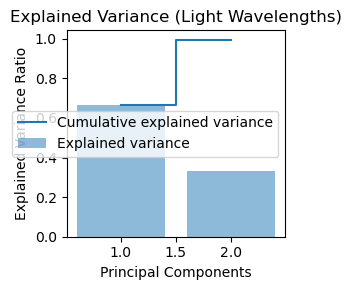

In [65]:
X_train_combined = X_train.drop(columns=columnsLightWavelengths)
X_train_combined = pd.concat([X_train_combined, pd.DataFrame(X_train_light_wavelengths_reduced,index=X_train_combined.index,columns=pca_column_names)], axis=1)
X_test_combined = X_test.drop(columns=columnsLightWavelengths)
X_test_combined = pd.concat([X_test_combined, pd.DataFrame(X_test_light_wavelengths_reduced,index=X_test_combined.index,columns=pca_column_names)], axis=1)
X_val_combined = X_val.drop(columns=columnsLightWavelengths)
X_val_combined = pd.concat([X_val_combined, pd.DataFrame(X_val_light_wavelengths_reduced,index=X_val_combined.index,columns=pca_column_names)], axis=1)
# Output the shapes of the reduced datasets
print("Reduced features shape (X_train):", X_train_combined.shape)
print("Reduced features shape (X_test):", X_test_combined.shape)
print("Reduced features shape (X_val):", X_val_combined.shape)
# Explained variance calculation
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance)
# Plot the explained variance for the light wavelength columns
plt.figure(figsize=(3, 3))
plt.bar(range(1, n_components_1+1), explained_variance[:n_components_1], alpha=0.5, align='center', label='Explained variance')
plt.step(range(1, n_components_1+1), cumulative_explained_variance[:n_components_1], where='mid', label='Cumulative explained variance')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance (Light Wavelengths)')
plt.legend(loc='best')
# Display the plot
plt.tight_layout()
plt.show()

In [66]:
y_train.shape

(2660,)

With 2 PCA components we can explain about 99% of explained variance

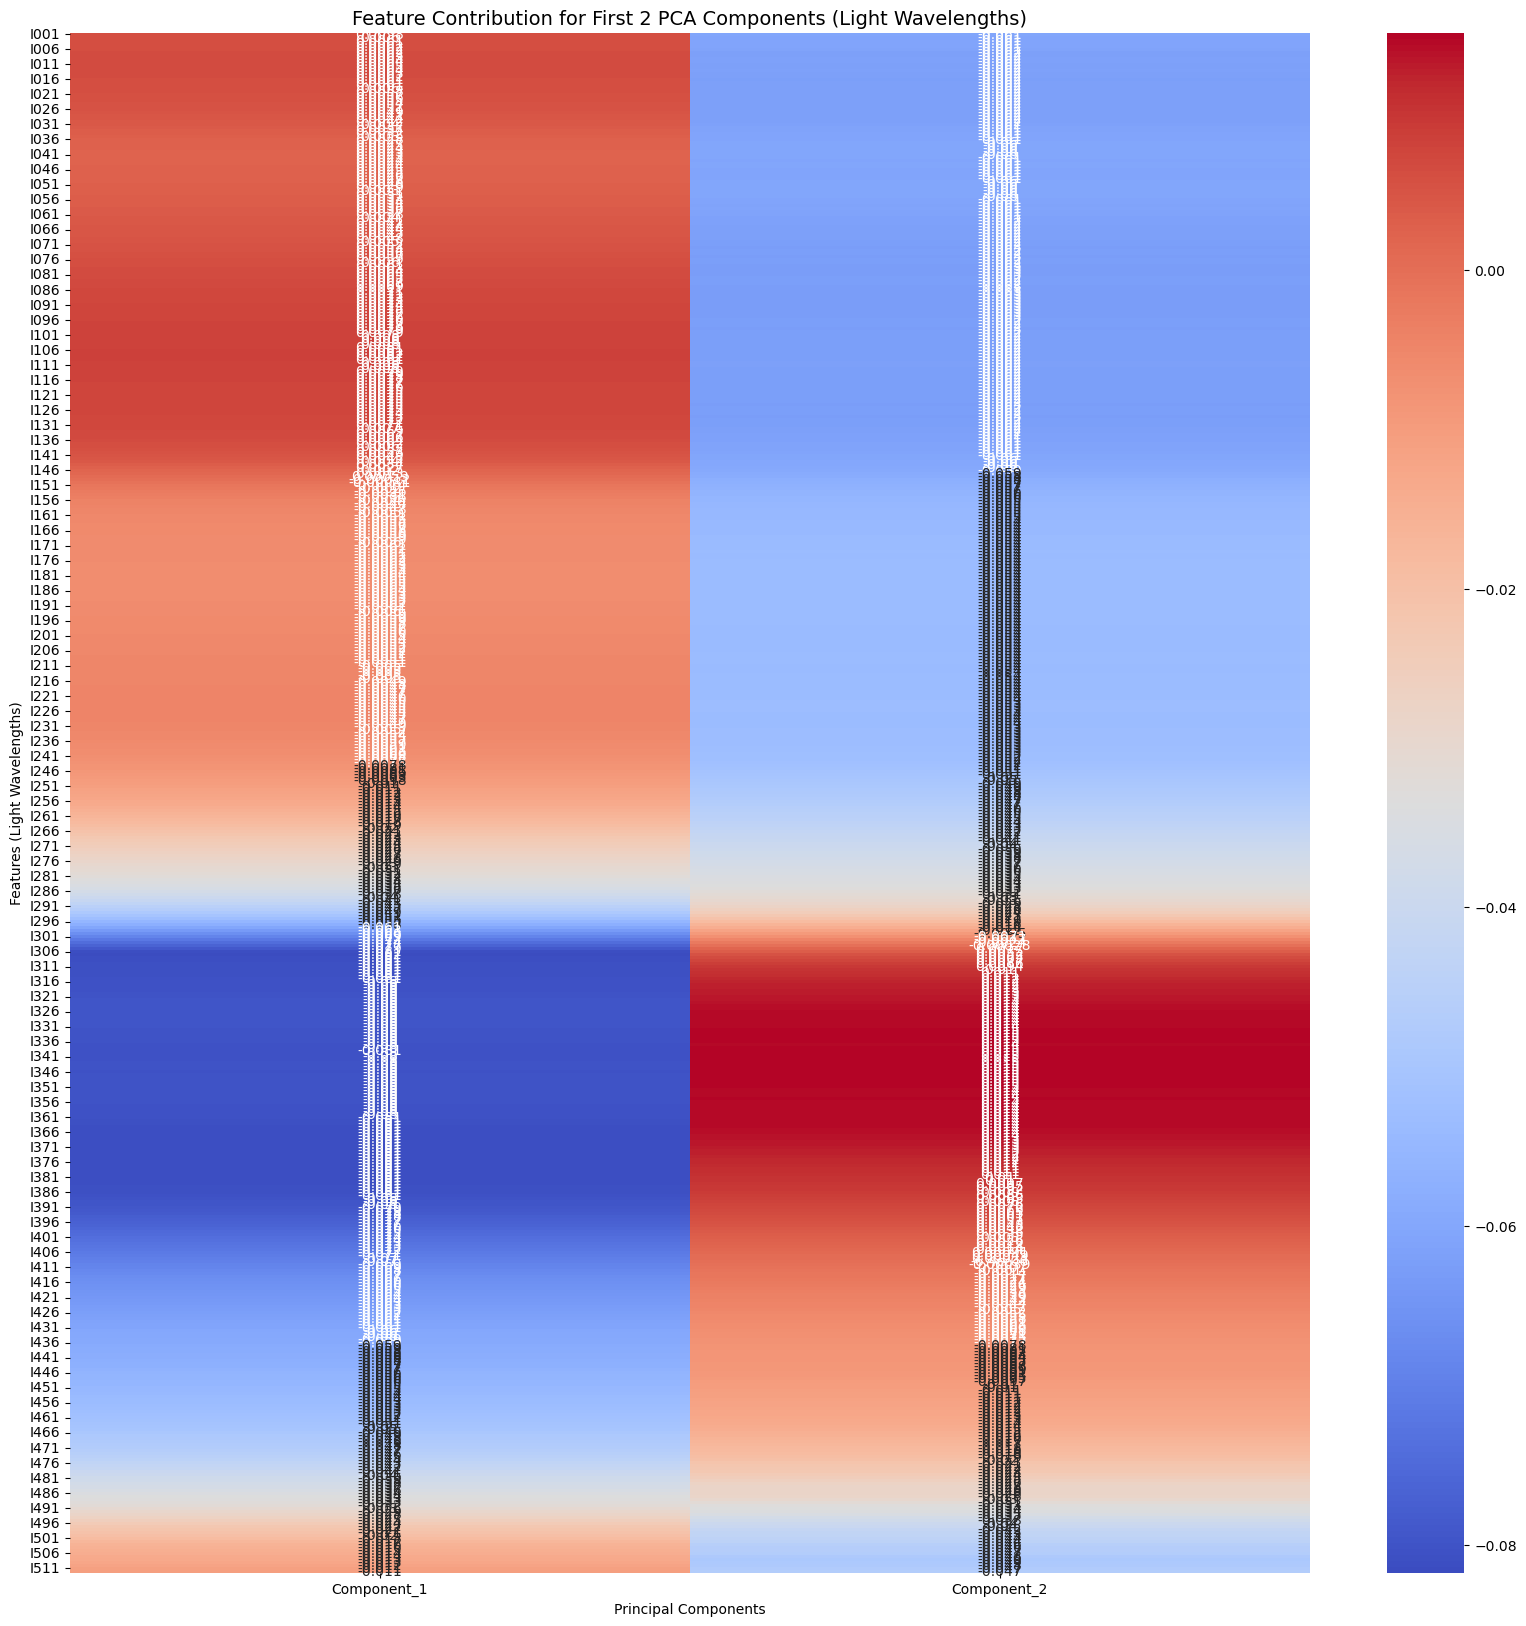

In [68]:
loadings = pca.components_[:2].T  # 
loadings_df = pd.DataFrame(loadings, index=columnsLightWavelengths, columns=[f'Component_{i+1}' for i in range(2)])
plt.figure(figsize=(20, 20))
sns.heatmap(loadings_df, annot=True, cmap='coolwarm', cbar=True)
plt.title("Feature Contribution for First 2 PCA Components (Light Wavelengths)", fontsize=14)
plt.xlabel("Principal Components")
plt.ylabel("Features (Light Wavelengths)")
plt.show()

Need to explainn this in report the feature contribution Part
First component seems to be mostly mapped from 1001 to I300, second component is mapped mostly from 1300 onwards

In [70]:
X_train_combined.head()

,TypeX,MatrixPbs,SID_S2,SID_S3,SID_S4,PCA_Component_1,PCA_Component_2
681,1,1,True,False,False,4.923231,5.342968
259,1,1,False,False,False,7.550815,-3.438816
849,1,1,True,False,False,-1.801627,-0.186392
2359,0,1,False,True,False,3.954057,3.128499
2615,0,1,False,True,False,-2.207080,1.547109


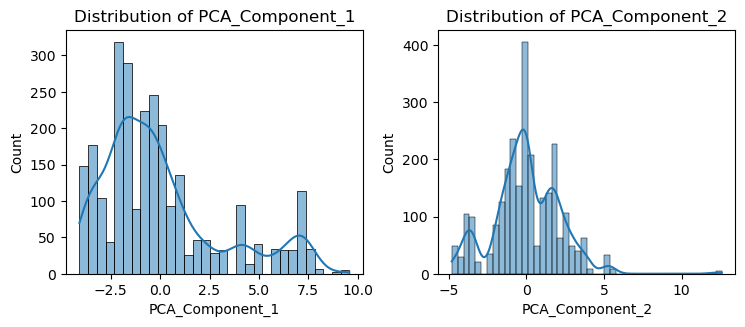

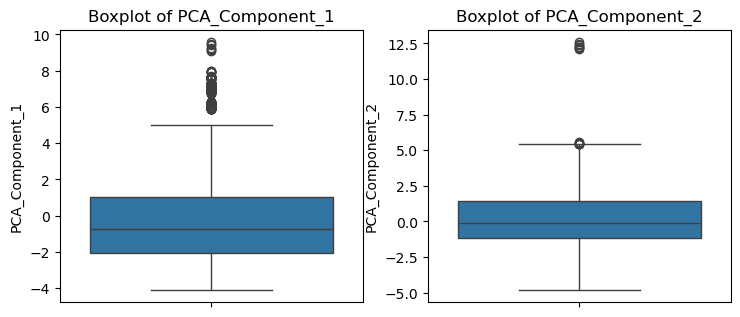

In [71]:
# Distribution plots for PCA features
PCA_Features =['PCA_Component_1','PCA_Component_2']
plt.figure(figsize=(15, 12))
for i, column in enumerate(PCA_Features, 1):
    plt.subplot(4, 4, i)
    sns.histplot(X_train_combined[column], kde=True)
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()
# Boxplots to detect outliers
plt.figure(figsize=(15, 12))
for i, column in enumerate(PCA_Features, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=X_train_combined[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

In [72]:
for col in PCA_Features:
    # Calculate the first (Q1) and third (Q3) quartiles, and the IQR (Interquartile Range)
    Q1 = X_train_combined[col].quantile(0.25)
    Q3 = X_train_combined[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate the lower and upper bounds for detecting outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap outliers in the training set: any value below lower_bound is set to lower_bound,
    # and any value above upper_bound is set to upper_bound
    X_train_combined[col] = X_train_combined[col].apply(
        lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x)
    )
    
    # Apply the same capping to the validation and test sets using the training data's bounds
    X_val_combined[col] = X_val_combined[col].apply(
        lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x)
    )
    
    X_test_combined[col] = X_test_combined[col].apply(
        lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x)
    )


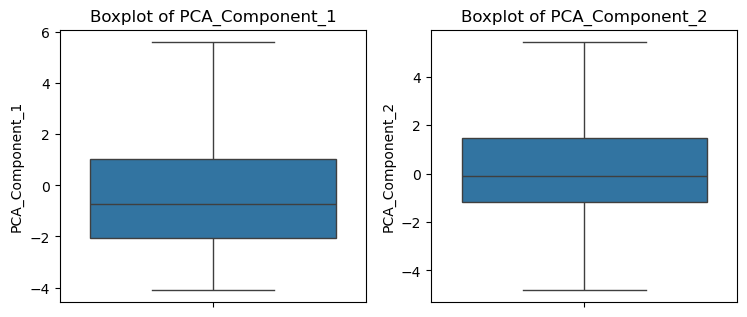

In [73]:

# Boxplots aftter removing outliers
plt.figure(figsize=(15, 12))
for i, column in enumerate(PCA_Features, 1):
    plt.subplot(4, 4, i)
    sns.boxplot(y=X_train_combined[column])
    plt.title(f'Boxplot of {column}')
plt.tight_layout()
plt.show()

In [74]:
#Running  Correlation again 

In [75]:
y_train.head()

681     1
259     3
849     4
2359    3
2615    8
Name: Load, dtype: int64

In [76]:
X_train_combined.head()

,TypeX,MatrixPbs,SID_S2,SID_S3,SID_S4,PCA_Component_1,PCA_Component_2
681,1,1,True,False,False,4.923231,5.342968
259,1,1,False,False,False,5.603819,-3.438816
849,1,1,True,False,False,-1.801627,-0.186392
2359,0,1,False,True,False,3.954057,3.128499
2615,0,1,False,True,False,-2.207080,1.547109


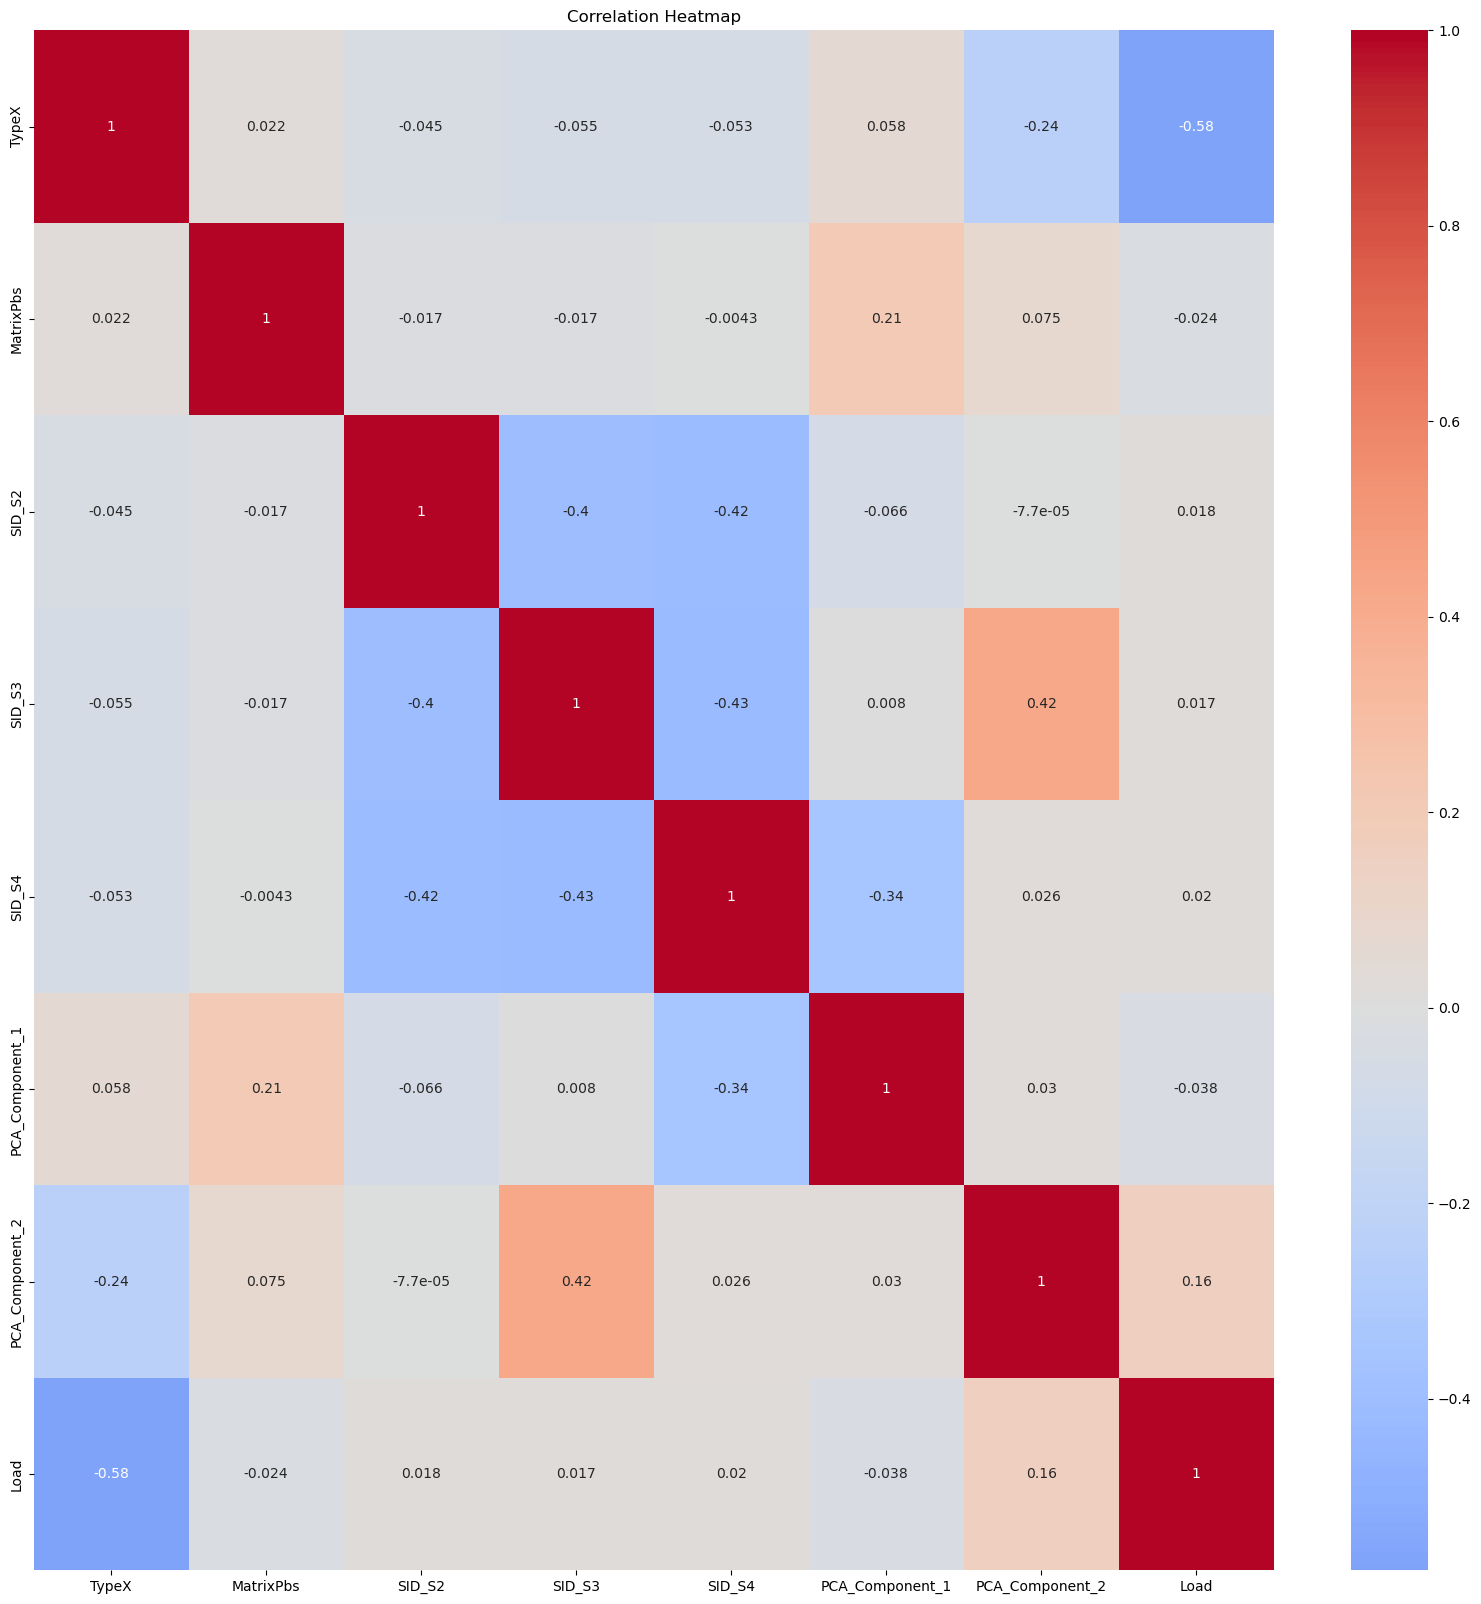

In [77]:
data_train= pd.concat([X_train_combined, y_train], axis=1)

correlation_matrix = data_train.corr()

plt.figure(figsize=(20,20))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [78]:
selected_features = []
remaining_features = [col for col in X_train_combined.columns ]  
best_score = float('-inf')
while remaining_features:
    scores_with_candidates = []
    for feature in remaining_features:
        features_to_test = selected_features + [feature]
        X_train_subset = X_train_combined[features_to_test]
        model = LinearRegression().fit(X_train_subset, y_train)
        score = model.score(X_val_combined[features_to_test], y_val)  # Evaluate on validation set
        scores_with_candidates.append((score, feature))
    scores_with_candidates.sort(reverse=True)
    best_new_score, best_candidate = scores_with_candidates[0]
    if best_new_score > best_score:
        selected_features.append(best_candidate)
        remaining_features.remove(best_candidate)
        best_score = best_new_score
    else:
        break  # Stop if no improvement

print("Selected features via forward selection:", selected_features)



Selected features via forward selection: ['TypeX', 'MatrixPbs', 'SID_S4', 'PCA_Component_2', 'SID_S3', 'SID_S2', 'PCA_Component_1']


All features useful so just going with all

### Model Selection: 
Experiment with algorithms such as Linear Regression, Ridge/Lasso, and Decision Trees. Hyperparameter tuning (e.g., grid search) can optimize performance. 

In [81]:
from sklearn.svm import SVR

# Define models, adding SVR (Support Vector Regression) as a non-linear model
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "SVR": SVR()  # Non-linear model added
}

# Define hyperparameters for GridSearchCV (or manual tuning if needed)
param_grids = {
    "Linear Regression": {},  # No tuning needed for Linear Regression
    "Ridge": {'alpha': [0.4, 0.5, 0.6, 10, 100]},  # Tuning for Ridge
    "Lasso": {'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01]},  # Tuning for Lasso
    "Decision Tree": {
        'max_depth': [5, 10, 15, 20, None],
        'min_samples_split': [4, 5, 10],
        'min_samples_leaf': [1, 2, 3]
    },
    "SVR": {
        'C': [100, 200, 500],  # Regularization parameter
        'epsilon': [0.3, 0.4, 0.5],  # Controls the width of the margin
        'kernel': ['linear', 'poly', 'rbf']  # Types of kernel functions
    }
}

# Cross-validation and hyperparameter tuning
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_models = {}

for model_name, model in models.items():
    best_score = -np.inf
    best_params = None
    
    # Tuning for Ridge, Lasso models (they use alpha)
    if model_name == "Ridge" or model_name == "Lasso":
        param_grid = param_grids[model_name]
        for params in param_grid.get('alpha', [None]):  # Adjust this if using different hyperparameters
            model.set_params(alpha=params)
            
            # Perform cross-validation on the validation set (X_val_combined, y_val)
            cv_scores = cross_val_score(model, X_val_combined[selected_features], y_val, cv=kf, scoring='neg_mean_squared_error')
            mean_cv_score = np.mean(cv_scores)
            
            if mean_cv_score > best_score:
                best_score = mean_cv_score
                best_params = params
        
        # Set the best model based on the best hyperparameters
        if best_params is not None:
            model.set_params(alpha=best_params)
    
    # Tuning for Decision Tree
    elif model_name == "Decision Tree":
        param_grid = param_grids[model_name]
        for max_depth in param_grid.get('max_depth', [None]):
            for min_samples_split in param_grid.get('min_samples_split', [2]):
                for min_samples_leaf in param_grid.get('min_samples_leaf', [1]):
                    model.set_params(max_depth=max_depth, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf)
                    
                    # Perform cross-validation on the validation set (X_val_combined, y_val)
                    cv_scores = cross_val_score(model, X_val_combined[selected_features], y_val, cv=kf, scoring='neg_mean_squared_error')
                    mean_cv_score = np.mean(cv_scores)
                    
                    if mean_cv_score > best_score:
                        best_score = mean_cv_score
                        best_params = {
                            'max_depth': max_depth,
                            'min_samples_split': min_samples_split,
                            'min_samples_leaf': min_samples_leaf
                        }
        
        # Set the best model based on the best hyperparameters
        if best_params is not None:
            model.set_params(**best_params)
    
    # Tuning for SVR
    elif model_name == "SVR":
        param_grid = param_grids[model_name]
        for C in param_grid['C']:
            for epsilon in param_grid['epsilon']:
                for kernel in param_grid['kernel']:
                    model.set_params(C=C, epsilon=epsilon, kernel=kernel)
                    
                    # Perform cross-validation on the validation set (X_val_combined, y_val)
                    cv_scores = cross_val_score(model, X_val_combined[selected_features], y_val, cv=kf, scoring='neg_mean_squared_error')
                    mean_cv_score = np.mean(cv_scores)
                    
                    if mean_cv_score > best_score:
                        best_score = mean_cv_score
                        best_params = {'C': C, 'epsilon': epsilon, 'kernel': kernel}
        
        # Set the best model based on the best hyperparameters
        if best_params is not None:
            model.set_params(**best_params)

    # Train the best model on the full training data (X_train_combined, y_train)
    best_models[model_name] = model.fit(X_train_combined[selected_features], y_train)
    print(f"Best model for {model_name}: {best_params}")

Best model for Linear Regression: None
Best model for Ridge: 0.5
Best model for Lasso: 0.001
Best model for Decision Tree: {'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 1}
Best model for SVR: {'C': 500, 'epsilon': 0.4, 'kernel': 'rbf'}



### Evaluation: 


Training Set - MSE: 2.7846, RMSE: 1.6687, R^2: 0.3484
Test Set - MSE: 2.8460, RMSE: 1.6870, R^2: 0.3334
RMSE Increase Percentage: 1.10%
R² Difference: 0.0150


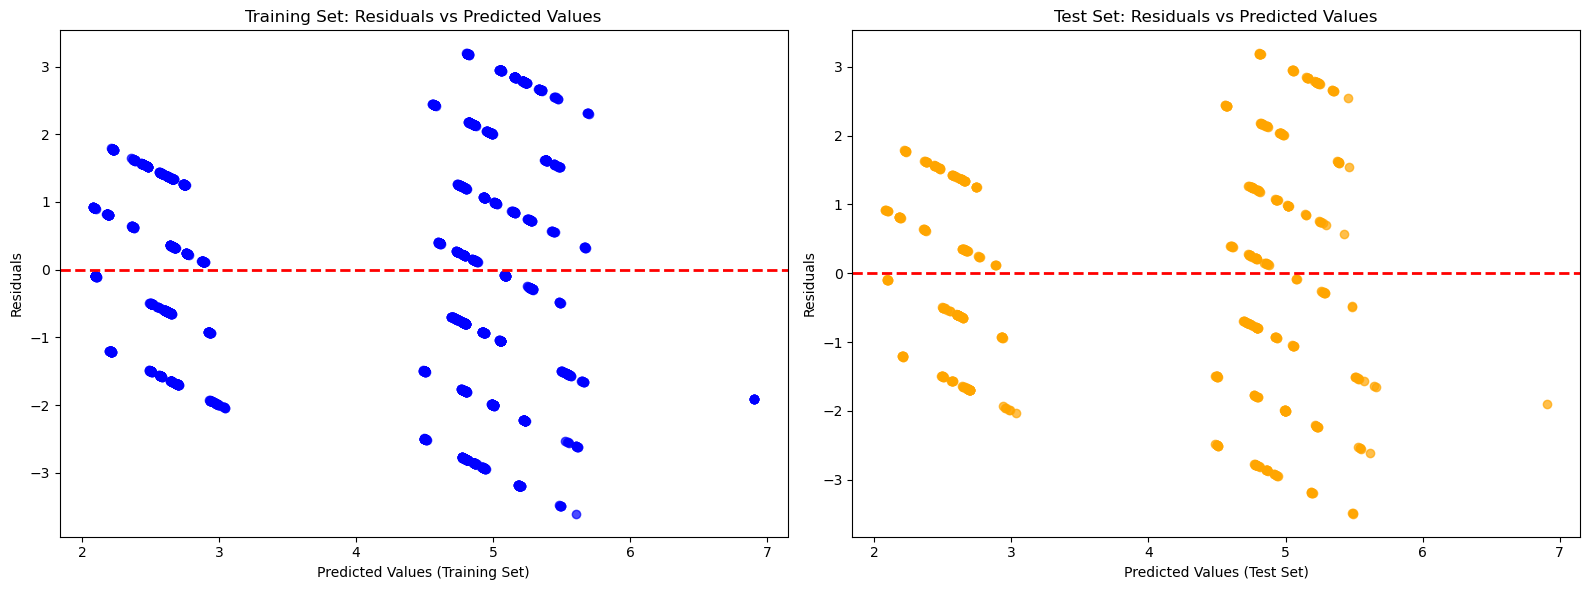

The model seems to be performing similarly on both training and test sets.
Linear Regression - Test MSE: 2.8460, RMSE: 1.6870, MAE: 1.4474, R^2: 0.3334, Correlation: 0.5776


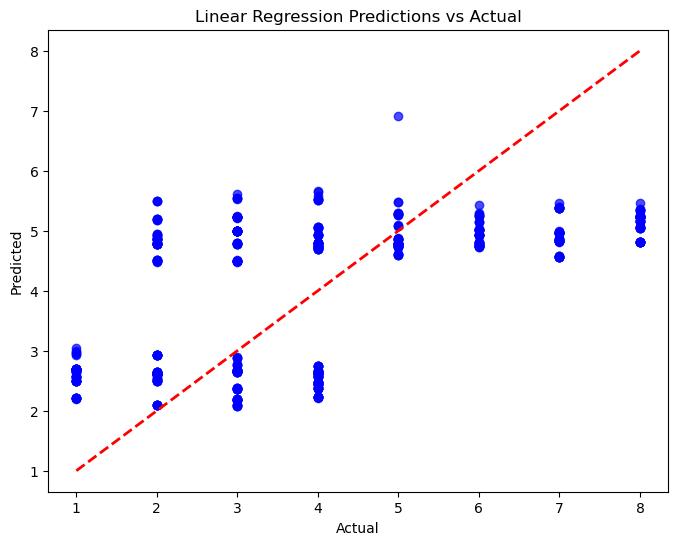

Regression formula for Linear Regression:
y = 6.5061 + -2.4244*TypeX + -0.0295*MatrixPbs + -1.7394*SID_S4 + 0.2062*PCA_Component_2 + -1.8374*SID_S3 + -1.5761*SID_S2 + -0.1231*PCA_Component_1
Feature importances for Linear Regression:
TypeX: 2.4244
MatrixPbs: 0.0295
SID_S4: 1.7394
PCA_Component_2: 0.2062
SID_S3: 1.8374
SID_S2: 1.5761
PCA_Component_1: 0.1231

Linear Regression Coefficients and Feature Importances:
           Feature  Coefficient  Absolute Coefficient
0            TypeX    -2.424433              2.424433
1        MatrixPbs    -0.029540              0.029540
2           SID_S4    -1.739405              1.739405
3  PCA_Component_2     0.206216              0.206216
4           SID_S3    -1.837361              1.837361
5           SID_S2    -1.576097              1.576097
6  PCA_Component_1    -0.123073              0.123073

R^2 Score for Linear Regression: 0.3334
Training Set - MSE: 2.7846, RMSE: 1.6687, R^2: 0.3484
Test Set - MSE: 2.8443, RMSE: 1.6865, R^2: 0.3338
RMSE In

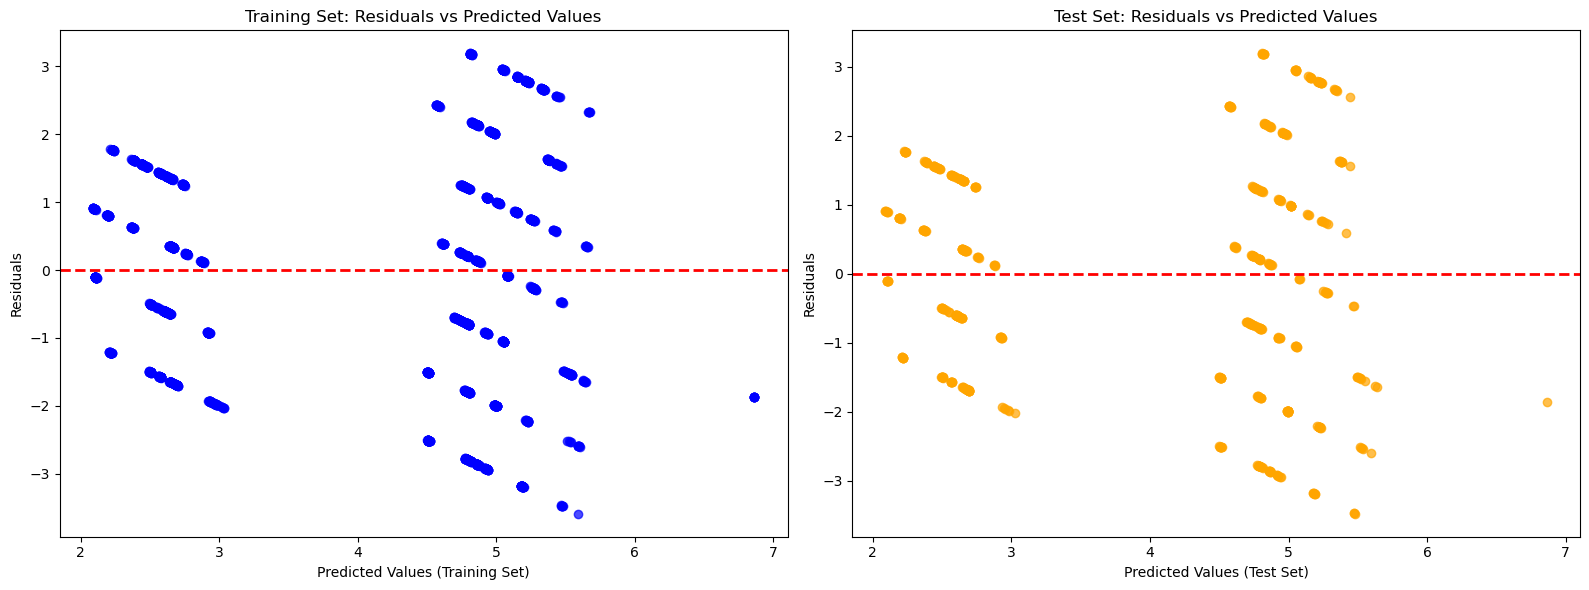

The model seems to be performing similarly on both training and test sets.
Ridge - Test MSE: 2.8443, RMSE: 1.6865, MAE: 1.4468, R^2: 0.3338, Correlation: 0.5779


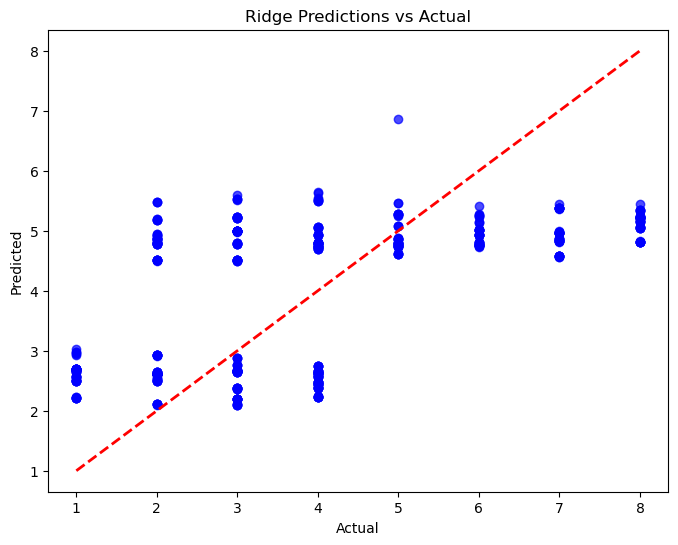

Regression formula for Ridge:
y = 6.4705 + -2.4219*TypeX + -0.0302*MatrixPbs + -1.6987*SID_S4 + 0.2021*PCA_Component_2 + -1.7954*SID_S3 + -1.5390*SID_S2 + -0.1203*PCA_Component_1
Feature importances for Ridge:
TypeX: 2.4219
MatrixPbs: 0.0302
SID_S4: 1.6987
PCA_Component_2: 0.2021
SID_S3: 1.7954
SID_S2: 1.5390
PCA_Component_1: 0.1203
Training Set - MSE: 2.7850, RMSE: 1.6688, R^2: 0.3483
Test Set - MSE: 2.8412, RMSE: 1.6856, R^2: 0.3345
RMSE Increase Percentage: 1.00%
R² Difference: 0.0138


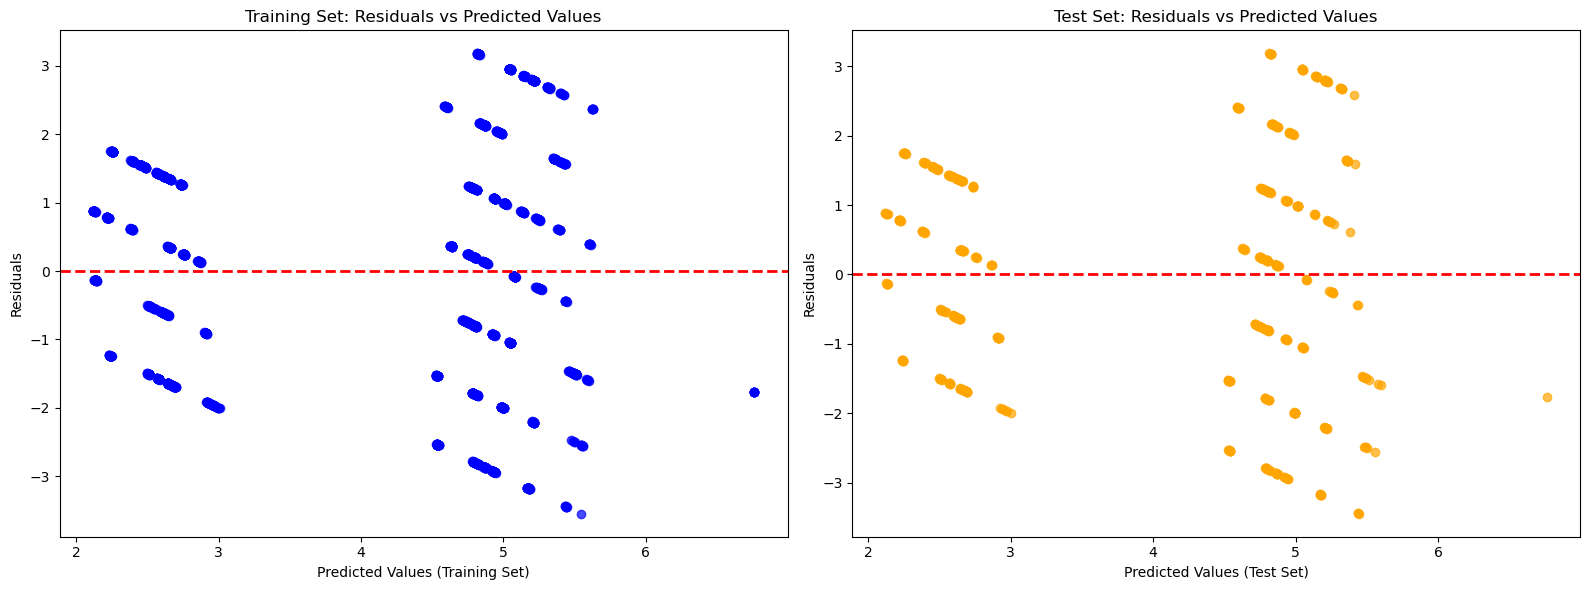

The model seems to be performing similarly on both training and test sets.
Lasso - Test MSE: 2.8412, RMSE: 1.6856, MAE: 1.4455, R^2: 0.3345, Correlation: 0.5785


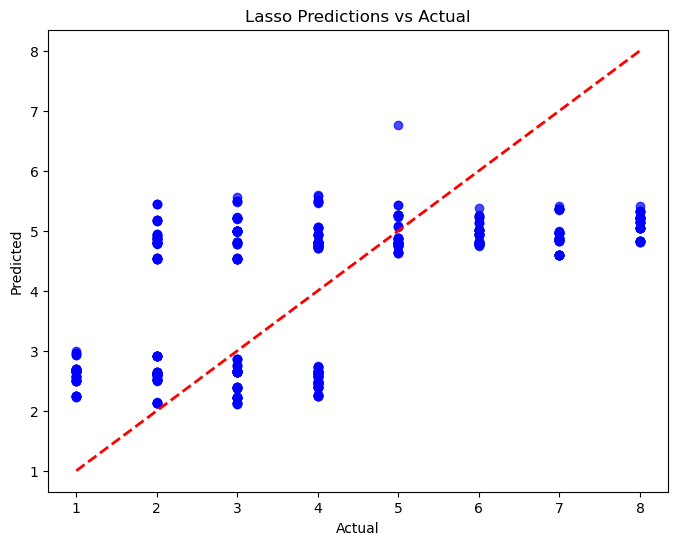

Regression formula for Lasso:
y = 6.3868 + -2.4186*TypeX + -0.0274*MatrixPbs + -1.6047*SID_S4 + 0.1921*PCA_Component_2 + -1.6980*SID_S3 + -1.4528*SID_S2 + -0.1138*PCA_Component_1
Feature importances for Lasso:
TypeX: 2.4186
MatrixPbs: 0.0274
SID_S4: 1.6047
PCA_Component_2: 0.1921
SID_S3: 1.6980
SID_S2: 1.4528
PCA_Component_1: 0.1138
Training Set - MSE: 0.0014, RMSE: 0.0371, R^2: 0.9997
Test Set - MSE: 0.0259, RMSE: 0.1609, R^2: 0.9939
RMSE Increase Percentage: 333.30%
R² Difference: 0.0057


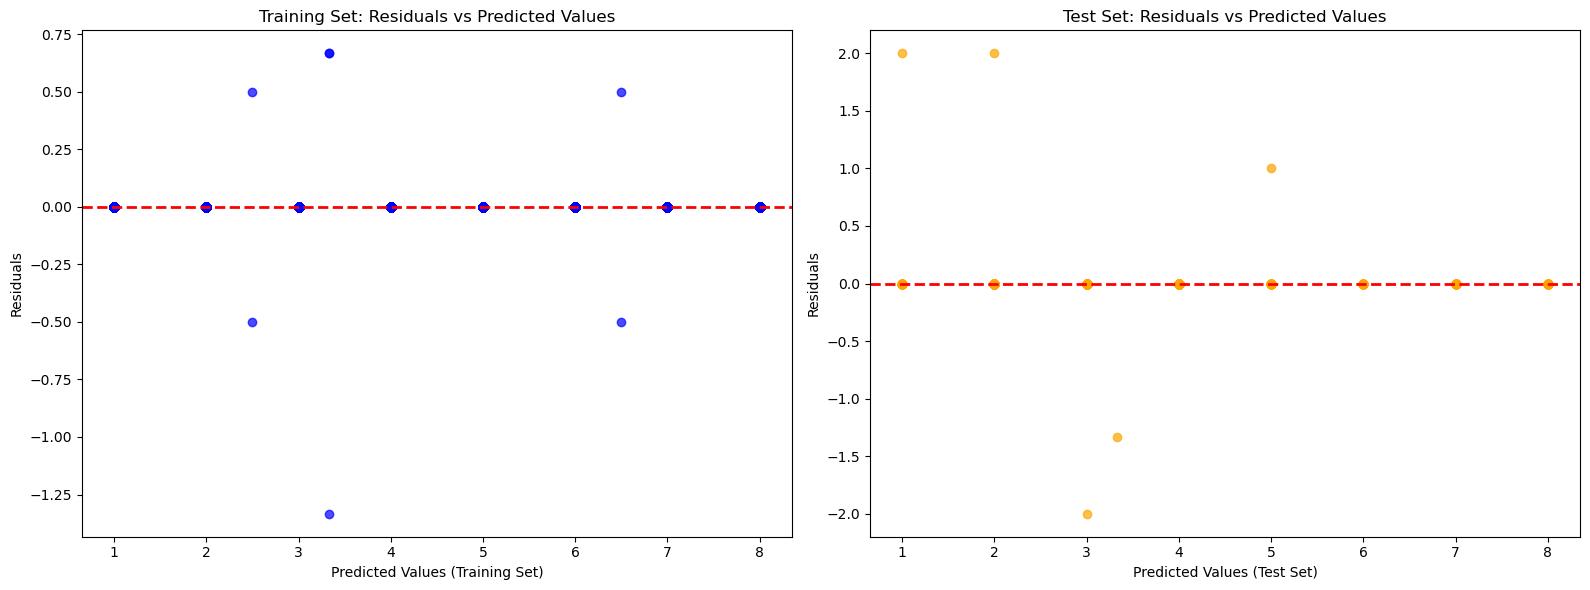

Potential overfitting: The model performs much better on the training set than the test set.
Decision Tree - Test MSE: 0.0259, RMSE: 0.1609, MAE: 0.0146, R^2: 0.9939, Correlation: 0.9970


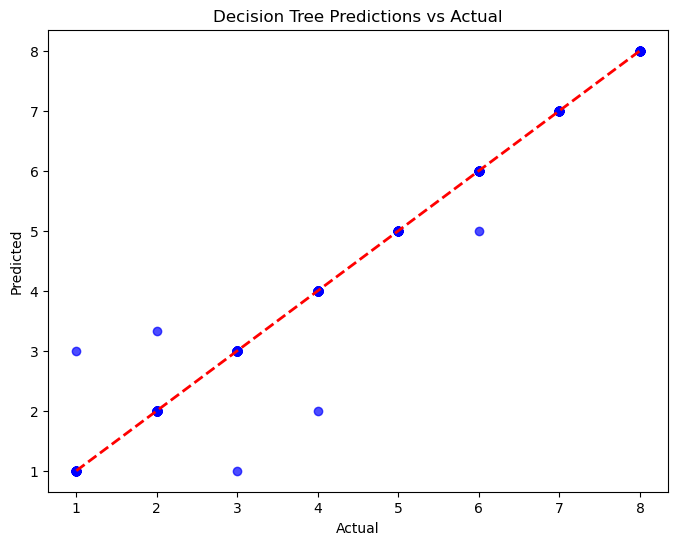

Feature importances for Decision Tree:
TypeX: 0.3312
MatrixPbs: 0.0306
SID_S4: 0.0352
PCA_Component_2: 0.3022
SID_S3: 0.0177
SID_S2: 0.0501
PCA_Component_1: 0.2329


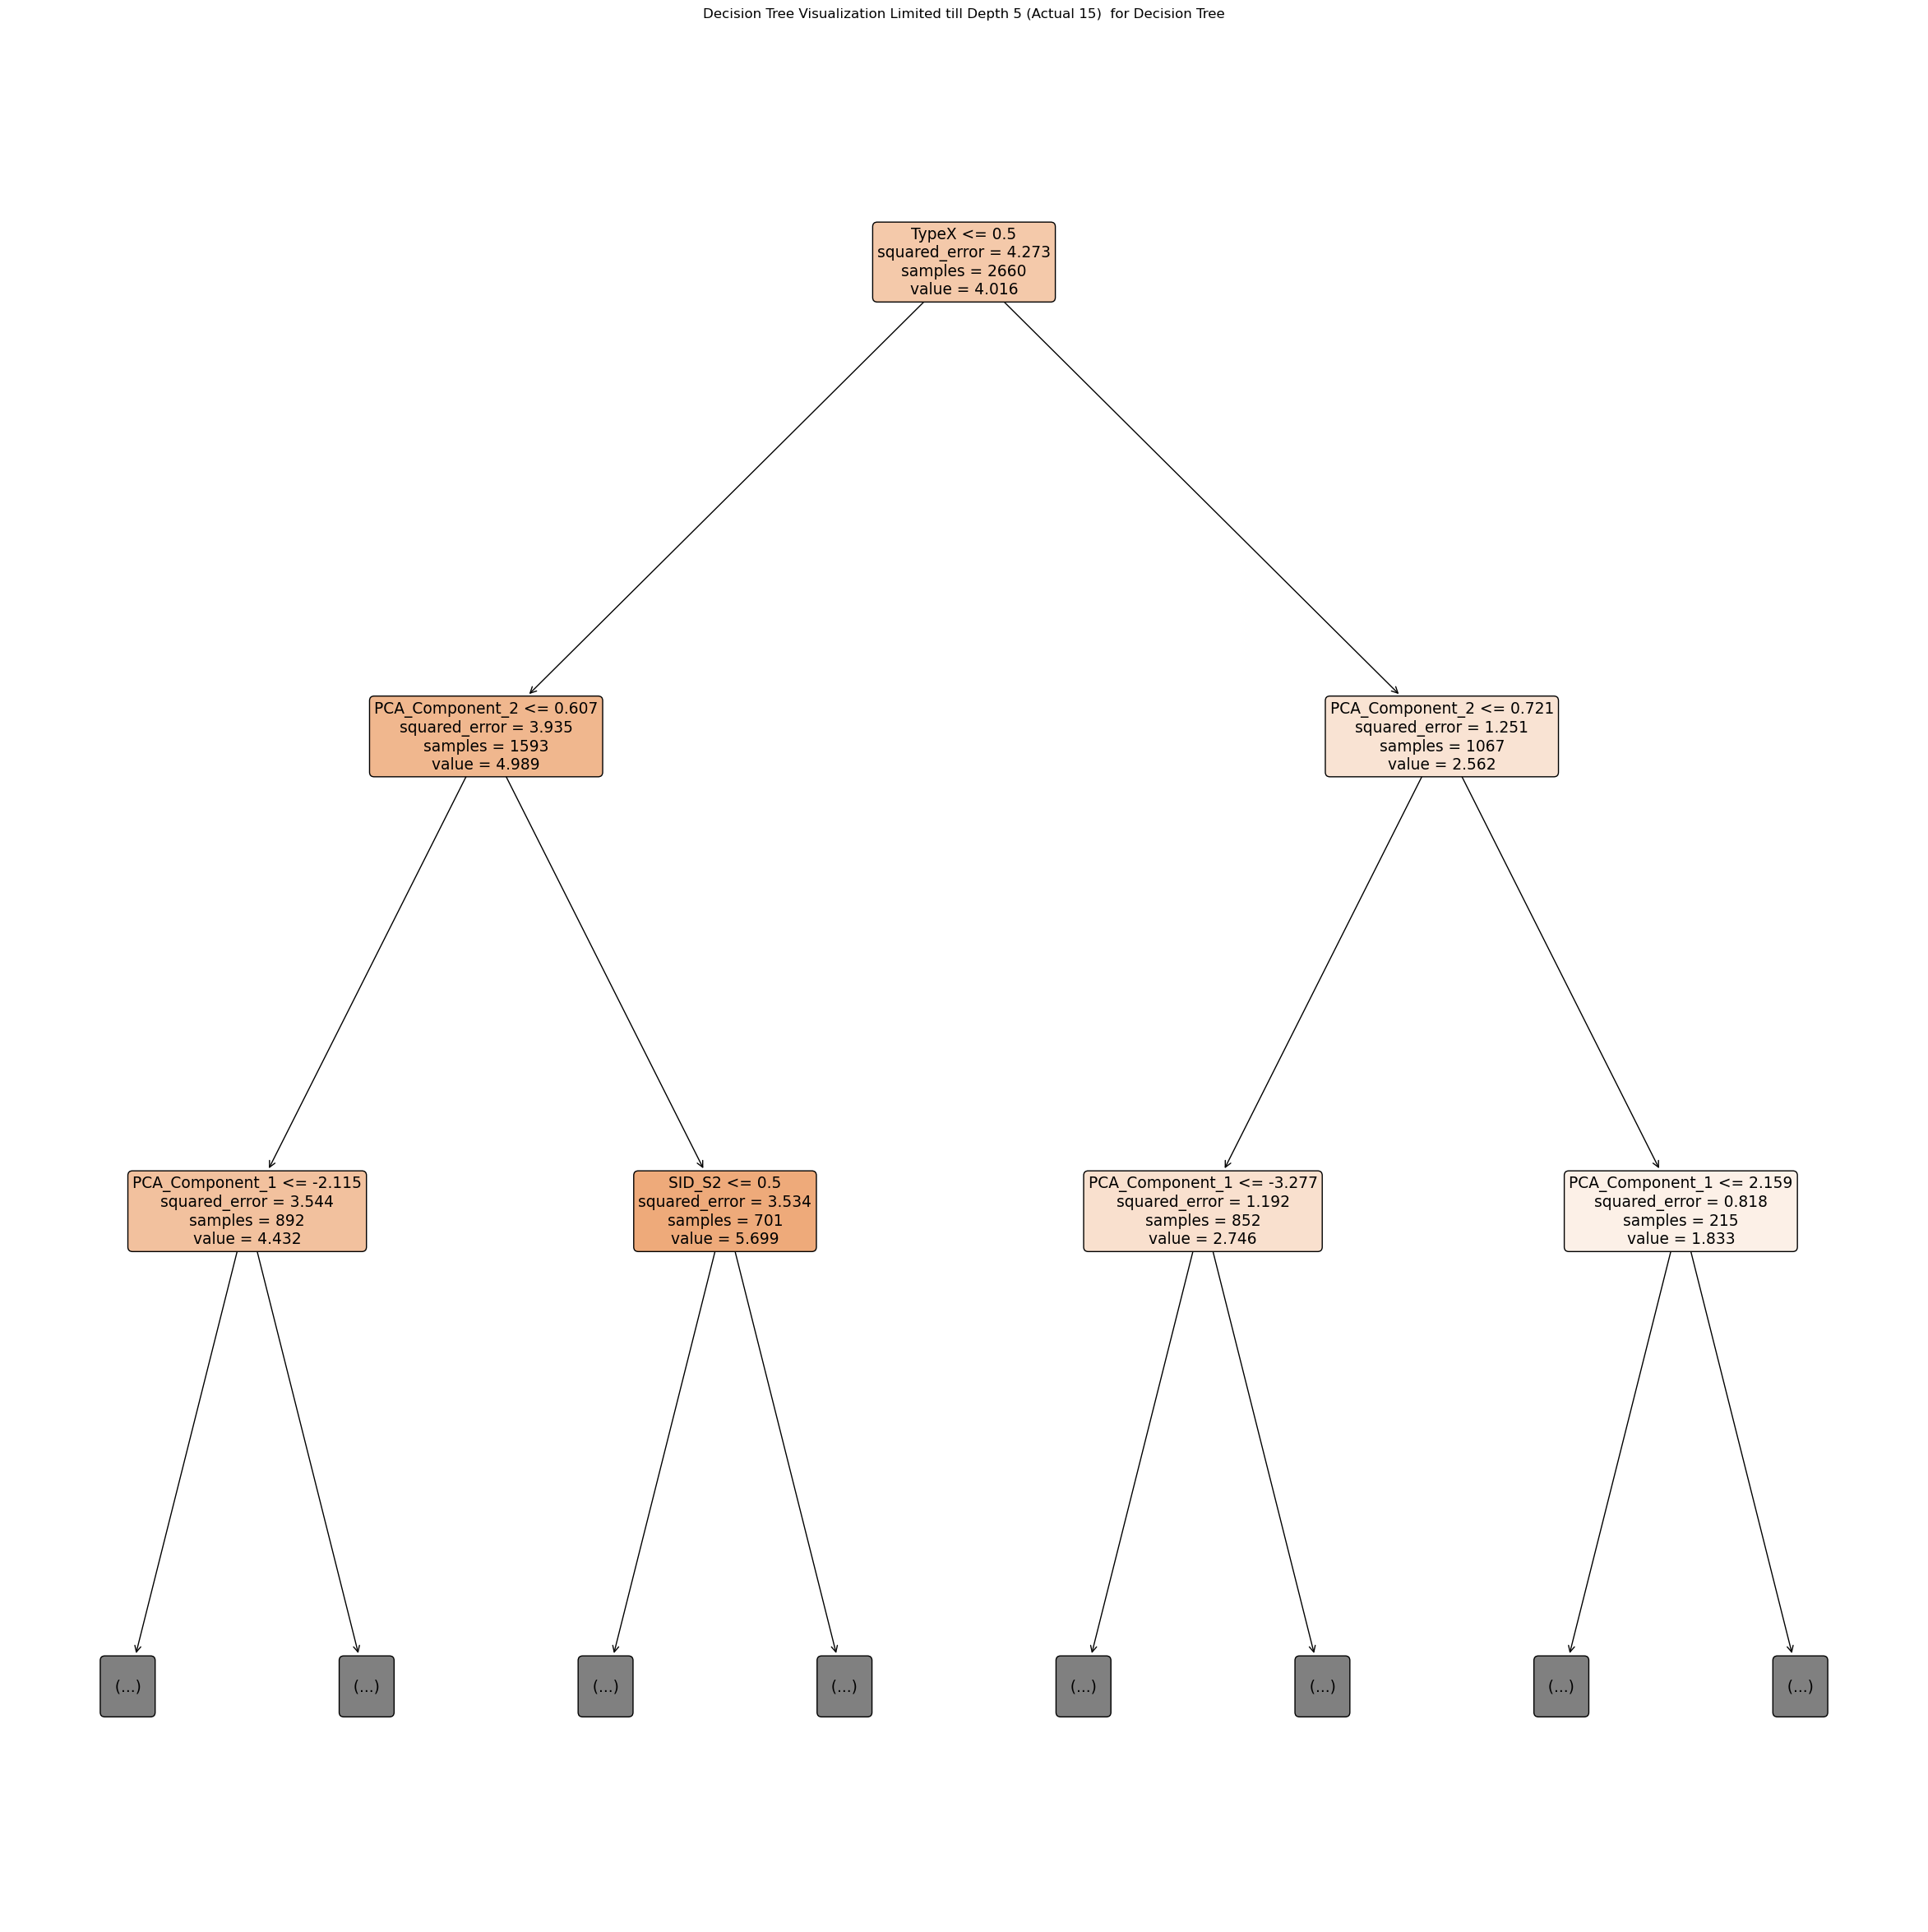

Training Set - MSE: 0.5474, RMSE: 0.7399, R^2: 0.8719
Test Set - MSE: 0.4742, RMSE: 0.6887, R^2: 0.8889
RMSE Increase Percentage: 6.92%
R² Difference: 0.0170


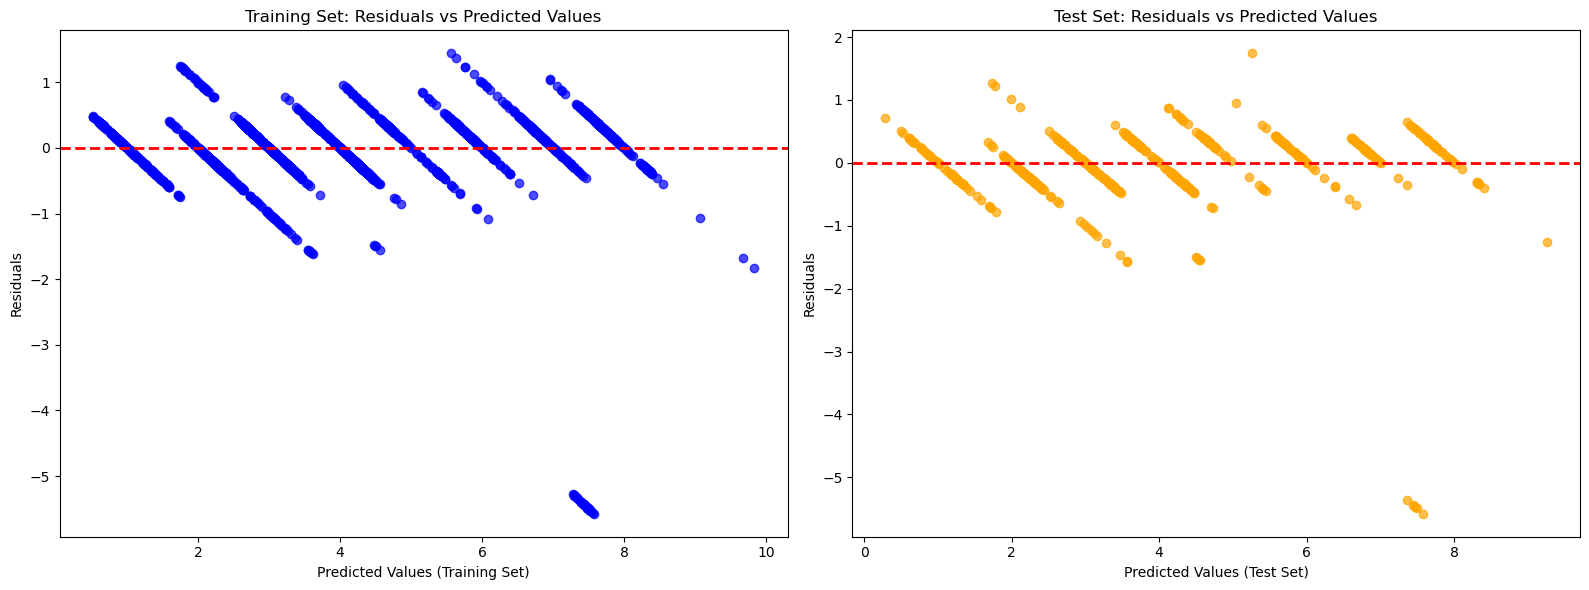

The model seems to be performing similarly on both training and test sets.
SVR - Test MSE: 0.4742, RMSE: 0.6887, MAE: 0.3710, R^2: 0.8889, Correlation: 0.9433


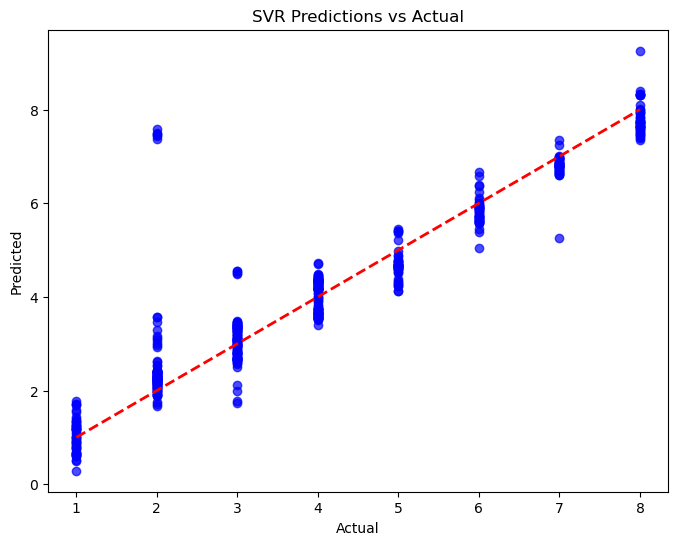

SVR model details:
Number of support vectors: 585


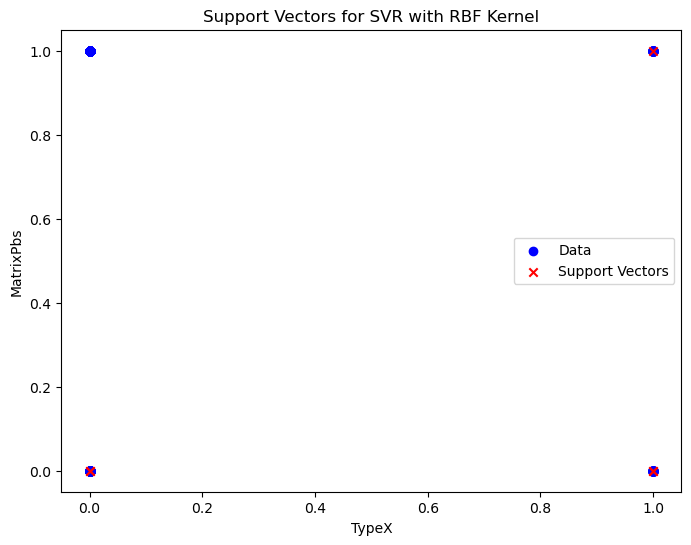

In [83]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import plot_tree

# Evaluate models on the test set
for model_name, model in best_models.items():
    # Predict on the test set
    y_test_pred = model.predict(X_test_combined[selected_features])
    y_train_pred = model.predict(X_train_combined[selected_features])
    # Calculate residuals
    train_residuals = y_train - y_train_pred
    test_residuals = y_test - y_test_pred
    
    # Calculate metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Print evaluation results for both sets
    print(f"Training Set - MSE: {train_mse:.4f}, RMSE: {train_rmse:.4f}, R^2: {train_r2:.4f}")
    print(f"Test Set - MSE: {test_mse:.4f}, RMSE: {test_rmse:.4f}, R^2: {test_r2:.4f}")
    rmse_increase_percentage = np.abs((test_rmse - train_rmse) / train_rmse) * 100

    # Calculate the R² difference
    r2_difference = np.abs(train_r2 - test_r2)
    
    # Print the results
    print(f"RMSE Increase Percentage: {rmse_increase_percentage:.2f}%")
    print(f"R² Difference: {r2_difference:.4f}")
    # Plot residuals for training and test sets
    plt.figure(figsize=(16, 6))
    
    # Training residuals plot
    plt.subplot(1, 2, 1)
    plt.scatter(y_train_pred, train_residuals, alpha=0.7, color='blue')
    plt.axhline(0, color='red', linestyle='--', linewidth=2)
    plt.xlabel("Predicted Values (Training Set)")
    plt.ylabel("Residuals")
    plt.title("Training Set: Residuals vs Predicted Values")
    
    # Test residuals plot
    plt.subplot(1, 2, 2)
    plt.scatter(y_test_pred, test_residuals, alpha=0.7, color='orange')
    plt.axhline(0, color='red', linestyle='--', linewidth=2)
    plt.xlabel("Predicted Values (Test Set)")
    plt.ylabel("Residuals")
    plt.title("Test Set: Residuals vs Predicted Values")
    
    plt.tight_layout()
    plt.show()
    
    # Check for overfitting or underfitting
    if train_rmse < test_rmse and test_r2 < train_r2 and (rmse_increase_percentage > 25 or r2_difference > 0.2):
        print("Potential overfitting: The model performs much better on the training set than the test set.")
    elif train_rmse > test_rmse and (rmse_increase_percentage > 25 or r2_difference > 0.2):
        print("Potential underfitting: The model may not be complex enough to capture the patterns in the training data.")
    else:
        print("The model seems to be performing similarly on both training and test sets.")
    # Calculate metrics
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    # Calculate correlation coefficient between actual and predicted values
    correlation = np.corrcoef(y_test, y_test_pred)[0, 1]
    
    # Print evaluation results
    print(f"{model_name} - Test MSE: {mse_test:.4f}, RMSE: {rmse_test:.4f}, MAE: {mae_test:.4f}, R^2: {r2_test:.4f}, Correlation: {correlation:.4f}")
    
    # Scatter plot for predictions vs actual values
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_test_pred, alpha=0.7, color="b")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{model_name} Predictions vs Actual")
    plt.show()

    # Feature importance for Decision Tree and regression coefficients for linear models
    if model_name == "Decision Tree":
        feature_importances = model.feature_importances_
        print(f"Feature importances for {model_name}:")
        for feature, importance in zip(selected_features, feature_importances):
            print(f"{feature}: {importance:.4f}")

        # Plot the decision tree
        plt.figure(figsize=(30, 30))
        plot_tree(model, max_depth=2,filled=True, feature_names=selected_features, class_names=[str(i) for i in range(1)], rounded=True)
        plt.title(f"Decision Tree Visualization Limited till Depth 5 (Actual 15)  for {model_name}")
        plt.show()

    elif model_name in ["Linear Regression", "Ridge", "Lasso"]:
        # Regression formula and coefficients
        print(f"Regression formula for {model_name}:")
        formula = " + ".join([f"{coef:.4f}*{feature}" for coef, feature in zip(model.coef_, selected_features)])
        print(f"y = {model.intercept_:.4f} + {formula}")
        
        # Variable importance (absolute value of coefficients for feature relevance)
        feature_importances = np.abs(model.coef_)
        print(f"Feature importances for {model_name}:")
        for feature, importance in zip(selected_features, feature_importances):
            print(f"{feature}: {importance:.4f}")
        
        # Print coefficients and R^2 in a tabular format for Linear Regression
        if model_name == "Linear Regression":
            coef_table = pd.DataFrame({
                "Feature": selected_features,
                "Coefficient": model.coef_,
                "Absolute Coefficient": np.abs(model.coef_)
            })
            print("\nLinear Regression Coefficients and Feature Importances:")
            print(coef_table)
            print(f"\nR^2 Score for {model_name}: {r2_test:.4f}")

    elif model_name == "SVR":
        # Make predictions on the test set


        # SVR model-specific details
        print(f"SVR model details:")
        print(f"Number of support vectors: {len(model.support_)}")
        
        # Visualize first few support vectors
        num_support_vectors_to_plot = 5  # Change as needed


        # For RBF kernel, let's visualize the first few support vectors
        support_vectors_indices = model.support_[:num_support_vectors_to_plot]
        support_vectors = X_test_combined.iloc[support_vectors_indices]

        plt.figure(figsize=(8, 6))
        plt.scatter(X_test_combined[selected_features[0]], X_test_combined[selected_features[1]], color='blue', label="Data")
        plt.scatter(support_vectors[selected_features[0]], support_vectors[selected_features[1]], color='red', label="Support Vectors", marker='x')
        plt.xlabel(selected_features[0])
        plt.ylabel(selected_features[1])
        plt.legend()
        plt.title(f"Support Vectors for SVR with RBF Kernel")
        plt.show()

## 2. Classification Approach
Transform the problem into a classification task to classify virus
type by predicting whether the subject has virus. Again, you need to design and justify
classification experiments including data preprocessing, feature engineering, model
selection, and evaluation; conduct experiments and analyse results, making full use of
the provided dses.


### Objective: 
Transform the task to classify virus presence (binary or multiclass based on virus types).

In [86]:
data.head()

,TypeX,MatrixPbs,Load,I001,I002,I003,I004,I005,I006,I007,...,I506,I507,I508,I509,I510,I511,I512,SID_S2,SID_S3,SID_S4
0,1,0,1,97.78,97.73,97.68,97.70,97.73,97.73,97.72,...,85.47,86.16,86.79,87.12,87.20,87.58,88.20,False,False,False
1,1,0,1,97.75,97.70,97.70,97.71,97.71,97.72,97.74,...,85.27,85.69,85.52,85.27,85.28,85.41,85.65,False,False,False
2,1,0,1,97.76,97.72,97.70,97.74,97.71,97.71,97.74,...,86.38,86.77,87.10,87.14,86.89,87.14,87.79,False,False,False
3,1,0,1,97.72,97.71,97.71,97.73,97.70,97.71,97.70,...,85.30,85.80,86.18,86.39,86.63,87.21,87.76,False,False,False
4,1,0,1,97.74,97.66,97.65,97.68,97.67,97.65,97.69,...,84.53,85.14,85.40,85.41,85.42,85.88,85.87,False,False,False


As i already did Pca, didn't do any transformation on type and Load feature in the last step, so will just import the pca implementation of wavelengths features part from the last step
, and resplit data prior to doing further eda and preprocessing for the new task 

In [567]:

X_all = pd.concat([X_train_combined, X_val_combined, X_test_combined], axis=0)
y_all = pd.concat([y_train, y_val, y_test], axis=0)

X_all['Load'] = y_all

y_all =  X_all['TypeX']

X_all = X_all.drop(columns=['TypeX'])  


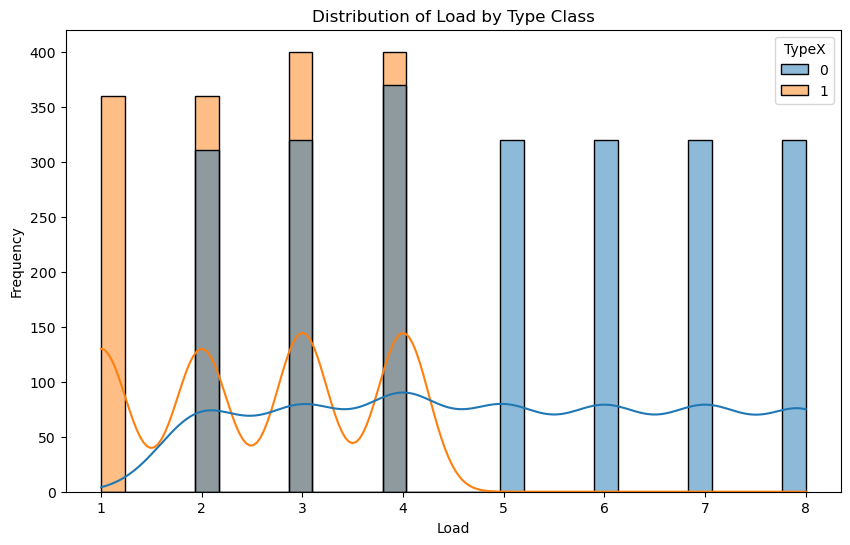

In [569]:
data_all_new=pd.concat([X_all, y_all], axis=1)


plt.figure(figsize=(10, 6))
sns.histplot(data=data_all_new, x='Load', hue='TypeX', bins=30, kde=True)
plt.title('Distribution of Load by Type Class')
plt.xlabel('Load')
plt.ylabel('Frequency')
plt.show()


In [570]:
#Want to stratify on Load and TypeX column when splitting Data
stratify_labels = data_all_new['Load'].astype(str) + "_" + data_all_new['TypeX'].astype(str)


In [571]:

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_all, y_all, test_size=0.3, stratify=stratify_labels, random_state=42)

print("New Training Set:", X_train_new.shape, y_train_new.shape)
print("New Test Set:", X_test_new.shape, y_test_new.shape)

New Training Set: (2660, 7) (2660,)
New Test Set: (1141, 7) (1141,)


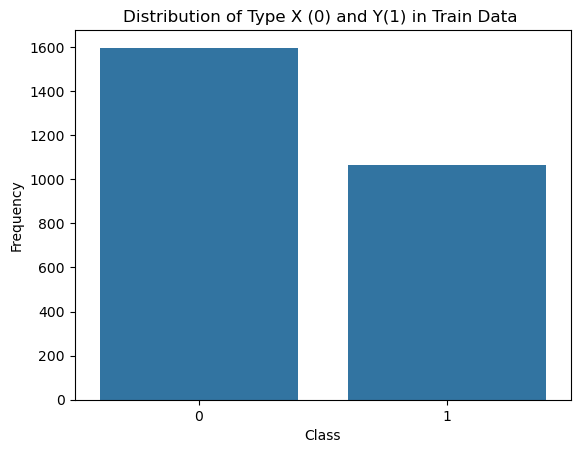

In [575]:
Type_counts = y_train_new.value_counts()

sns.barplot(x=Type_counts.index, y=Type_counts.values)
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Distribution of Type X (0) and Y(1) in Train Data ')
plt.show()

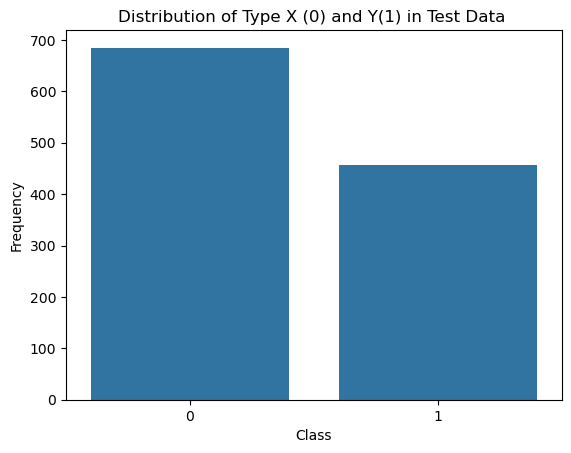

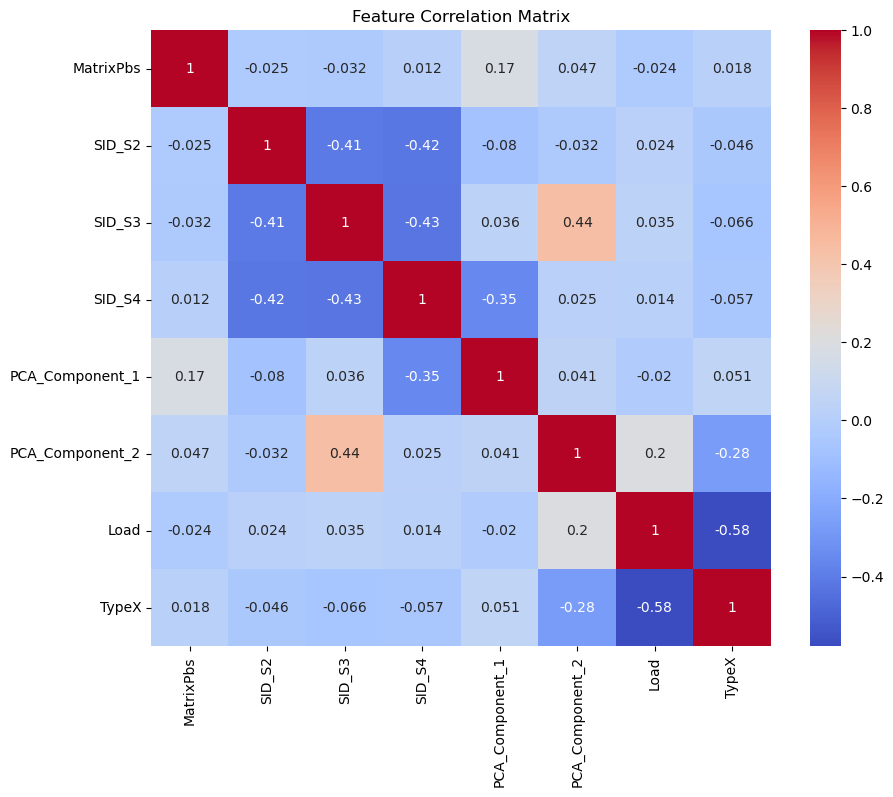

In [577]:
Type_counts_test = y_test_new.value_counts()

sns.barplot(x=Type_counts_test.index, y=Type_counts_test.values)
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Distribution of Type X (0) and Y(1) in Test Data ')
plt.show()
data_train_new=pd.concat([X_train_new, y_train_new], axis=1)
correlation_matrix = data_train_new.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


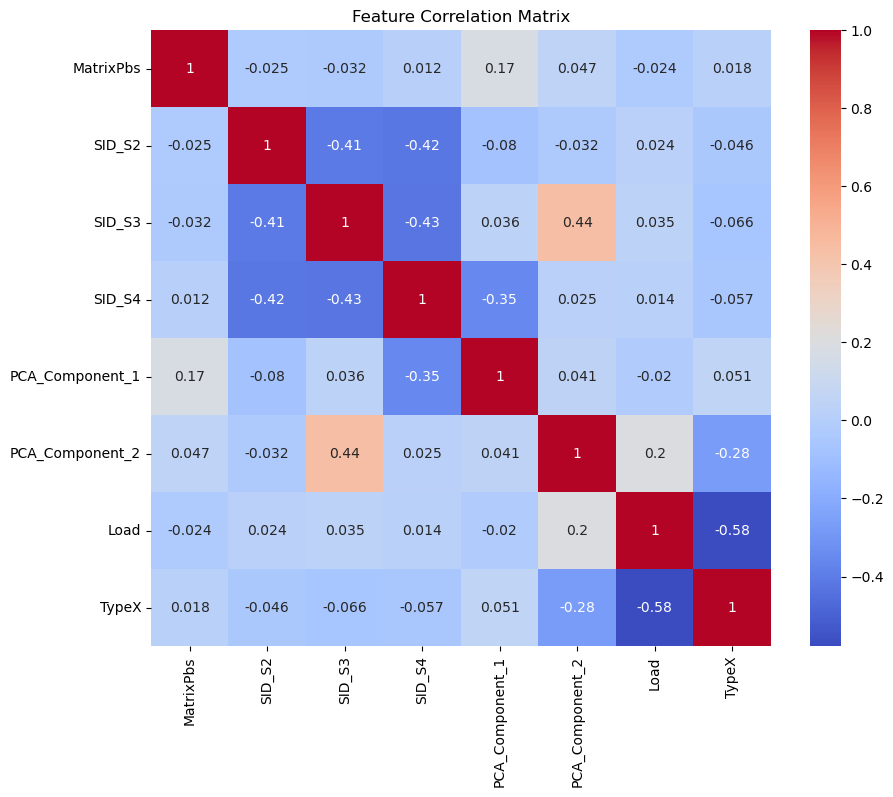

In [578]:
data_train_new=pd.concat([X_train_new, y_train_new], axis=1)
correlation_matrix = data_train_new.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

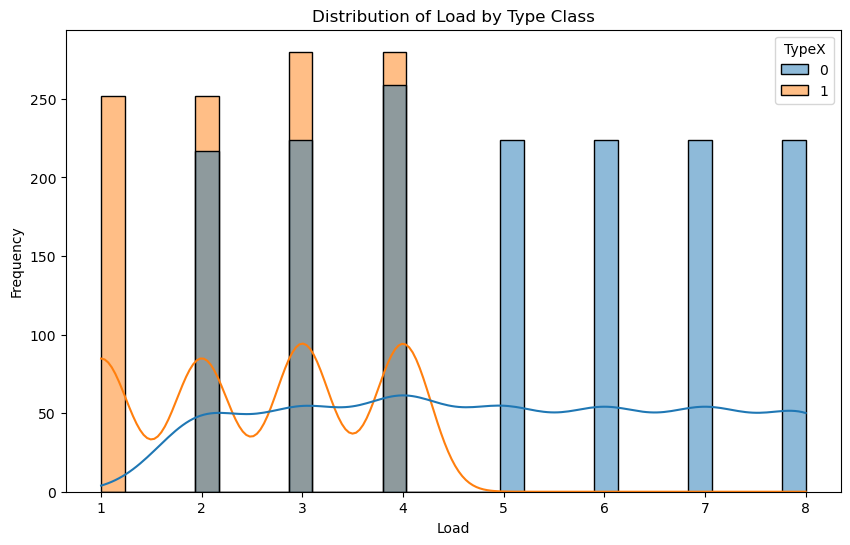

In [580]:
data_train_new=pd.concat([X_train_new, y_train_new], axis=1)


plt.figure(figsize=(10, 6))
sns.histplot(data=data_train_new, x='Load', hue='TypeX', bins=30, kde=True)
plt.title('Distribution of Load by Type Class')
plt.xlabel('Load')
plt.ylabel('Frequency')
plt.show()


In [583]:

# we can see in training data Loads 5-8 have just Type Y, Load 1 just has Type X , Loads 2-4 are the ones really which have some variation in X and Y; we can create a binned version of Load feature to use in modelling instead.
bins = [-np.inf, 1, 2,3,4, np.inf]  # Example bin edges, adjust these based on plot
labels = [1, 2,3, 4, 5]

# Create the binned_load feature
X_train_new['LoadCapped5'] = pd.cut(X_train_new['Load'], bins=bins, labels=labels)


# View the first few rows to confirm
print(X_train_new[['Load', 'LoadCapped5']].value_counts())



Load  LoadCapped5
4     4              539
3     3              504
2     2              469
1     1              252
5     5              224
6     5              224
7     5              224
8     5              224
Name: count, dtype: int64


In [585]:
# Use the same bins to transform the test set
X_test_new['LoadCapped5'] = pd.cut(X_test_new['Load'], bins=bins, labels=labels)


In [587]:
#creating interaction between some correlated features to see if they come up more useful than exisiting feature4s
X_train_new['PCA_Component_1SID_S4'] = X_train_new['PCA_Component_1'] *   X_train_new['SID_S4']

X_test_new['PCA_Component_1SID_S4'] = X_test_new['PCA_Component_1'] *   X_test_new['SID_S4']


In [1054]:
data_train_new=pd.concat([X_train_new, y_train_new], axis=1)


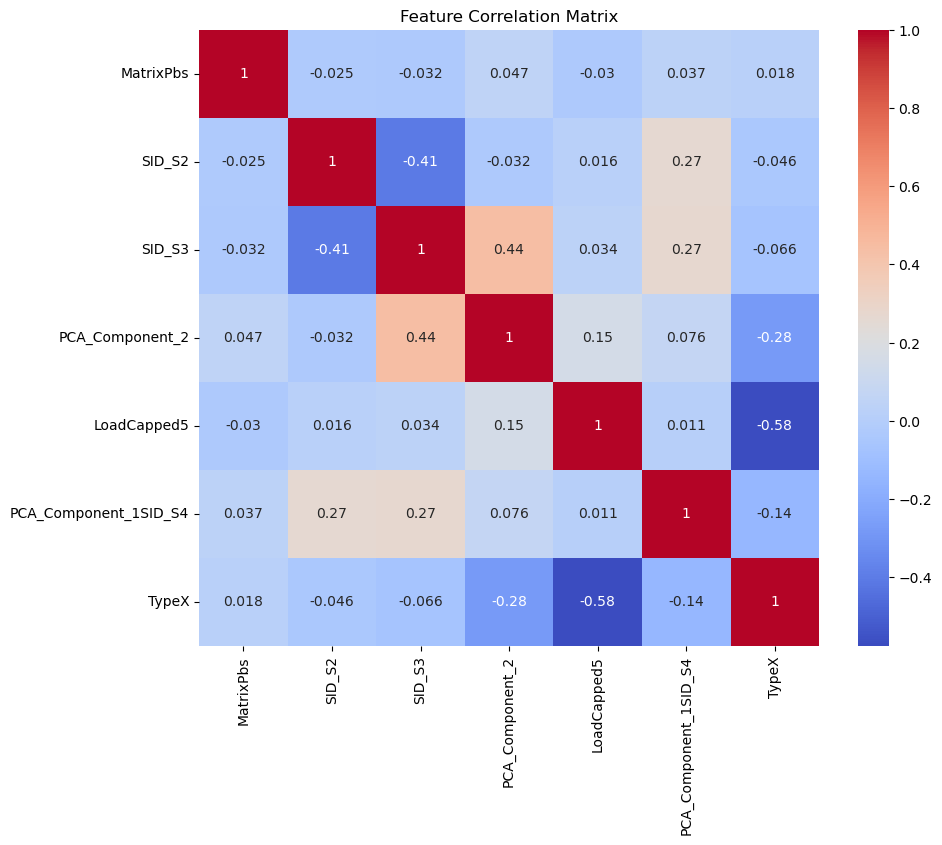

In [591]:
#The newly created Interaction PCA_component1*SID_4 feature is better correlated with type feature and has somewhat lower correlation with other features , Load Capped 5 is representing the info in Load 
# so dropping columns Load, PCA Component 1, SID_S4 

X_train_new = X_train_new.drop(columns=['Load', 'SID_S4','PCA_Component_1'])
X_test_new = X_test_new.drop(columns=['Load', 'SID_S4','PCA_Component_1'])

data_train_new=pd.concat([X_train_new, y_train_new], axis=1)
correlation_matrix = data_train_new.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [648]:
print(X_train_new['SID_S2'].unique())
print(X_train_new['SID_S3'].unique())

X_train_new['SID_S2'] = pd.factorize(X_train_new['SID_S2'])[0]
X_train_new['SID_S3'] = pd.factorize(X_train_new['SID_S3'])[0]

print(X_train_new[['SID_S2', 'SID_S3']].value_counts())


[0 1]
[0 1]
SID_S2  SID_S3
1       0         1120
        1          783
0       0          757
Name: count, dtype: int64


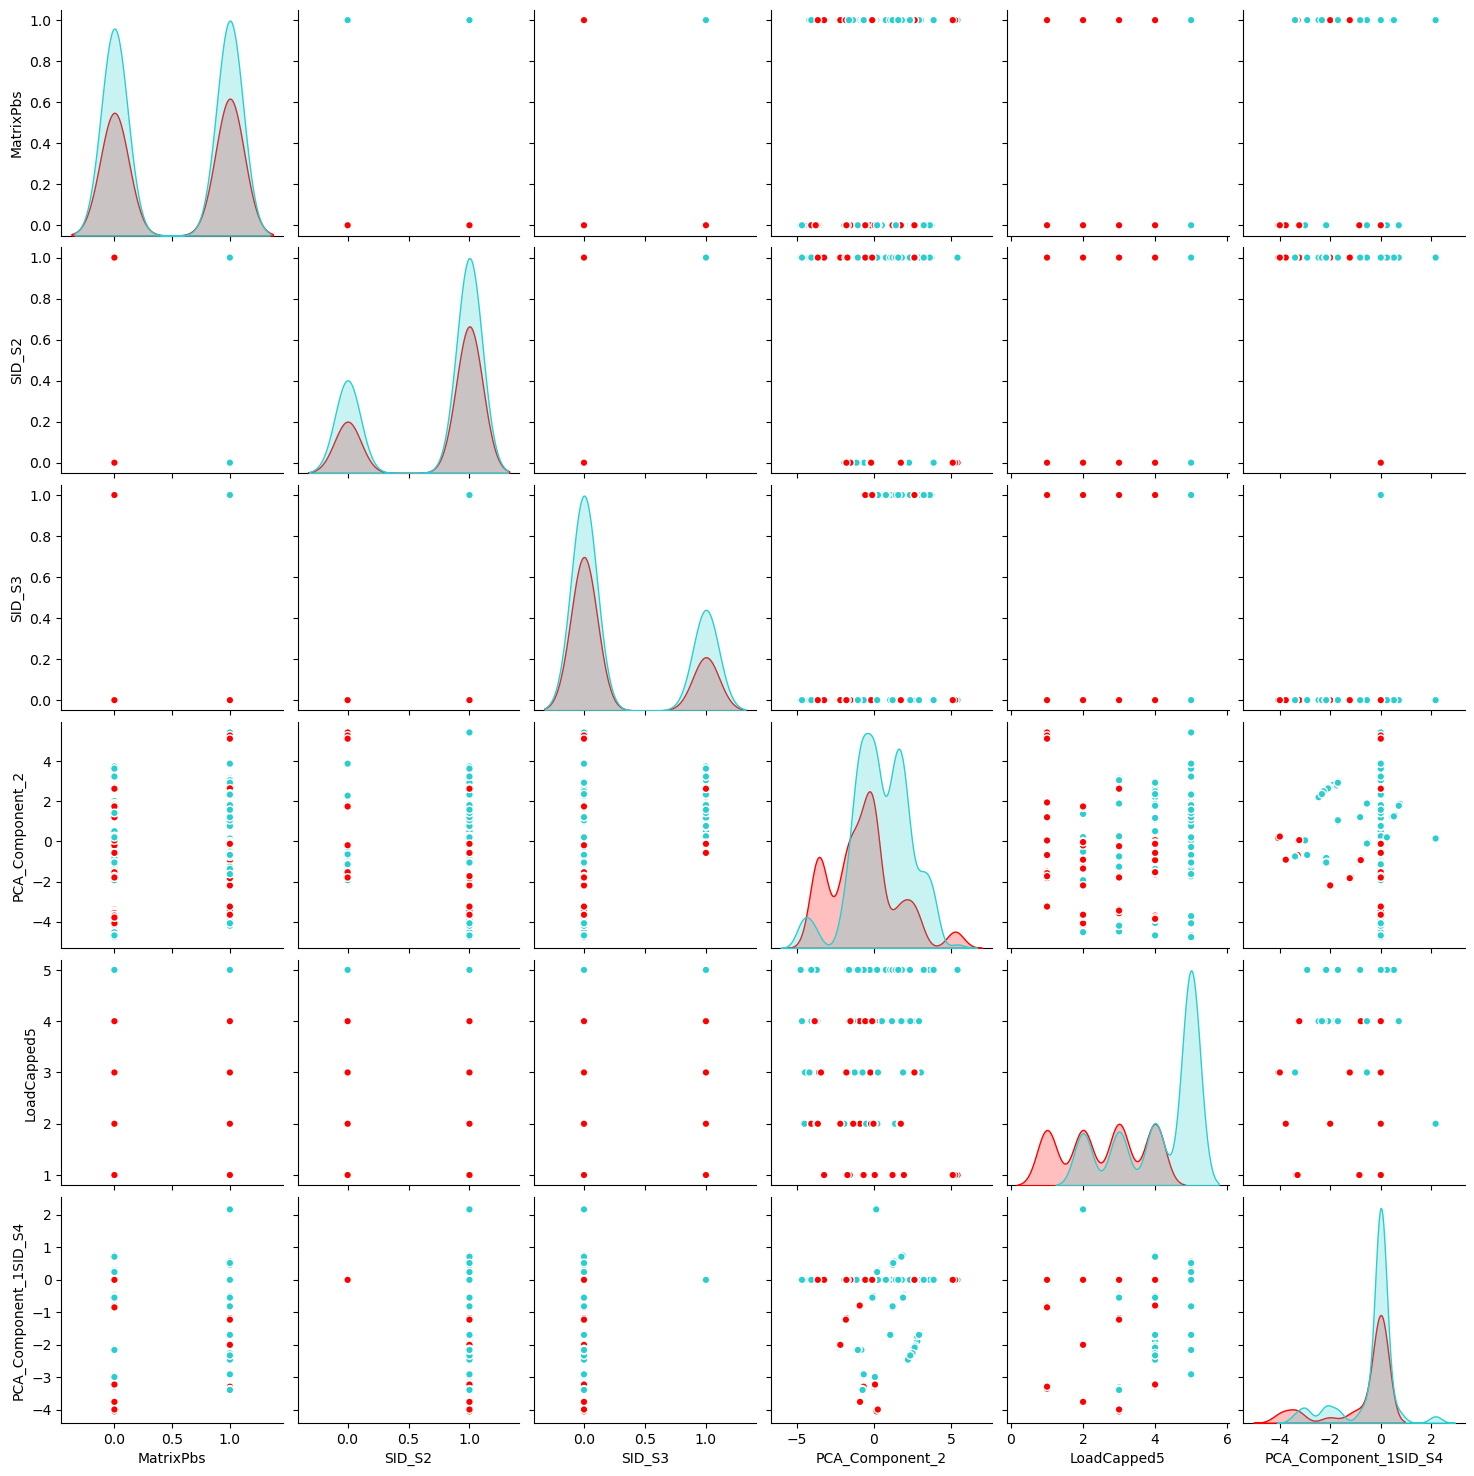

In [650]:
X_train_plot = X_train_new.apply(pd.to_numeric, errors='coerce')

# Check for any non-numeric columns and remove them if needed
non_numeric_columns = X_train_plot.select_dtypes(exclude=['number']).columns
if len(non_numeric_columns) > 0:
    print(f"Removing non-numeric columns: {non_numeric_columns.tolist()}")
    X_train_plot = X_train_plot.drop(columns=non_numeric_columns)

# Combine X and y data to create the complete training DataFrame for plotting
data_plot_new = X_train_plot.copy()
data_plot_new[target] = y_train_new

# Define features and ensure target is in the data
features = X_train_plot.columns.tolist()

# Plotting with pairplot
pairplot = sns.pairplot(
    data_plot_new, vars=features, kind="scatter", hue=target,
    palette=['#29CFD0', '#FF0000'], plot_kws=dict(s=30, linewidth=1)
)

# Remove the legend if needed
pairplot._legend.remove()

In [595]:
#X_train_new_pd.head()

#### Feature Scaling

In [593]:

# Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_new)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train_new.columns)
X_test_scaled = scaler.transform(X_test_new)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_train_new.columns)


#### Feature selection

In [597]:
# Deviance Function
def deviance(X, y, model):
    return 2 * log_loss(y, model.predict_proba(X), normalize=False)

# Subset Deviance Calculation
def subset_deviance(model, X, y, selected_ids):
    X_selected = X.iloc[:, sorted(list(selected_ids))]
    model.fit(X_selected, y)
    return deviance(X_selected, y, model)

# Feature Selection by Deviance
def select_features_by_deviance(X, y, model, max_features=None):
    n_features = X.shape[1]
    selected_ids = set()
    best_deviance = float('inf')
    
    for num_features in range(1, n_features + 1):
        if max_features and num_features > max_features:
            break
        
        for feature_ids in combinations(range(n_features), num_features):
            dev = subset_deviance(model, X, y, feature_ids)
            if dev < best_deviance:
                best_deviance = dev
                selected_ids = set(feature_ids)
                
    return [X.columns[i] for i in sorted(list(selected_ids))]

# Feature Selection
print("Performing feature selection based on deviance...")
selected_features = select_features_by_deviance(X_train_scaled_df, y_train_new, LogisticRegression(max_iter=1000, class_weight='balanced'))
print(f"Selected features based on deviance: {selected_features}")

Performing feature selection based on deviance...
Selected features based on deviance: ['MatrixPbs', 'SID_S2', 'SID_S3', 'PCA_Component_2', 'LoadCapped5', 'PCA_Component_1SID_S4']



Best params for Logistic Regression: {'C': 10}, Best CV Score: 0.7594

Logistic Regression - Train Accuracy: 0.7662, Test Accuracy: 0.7555
Logistic Regression is well-fitted to the data.
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.77      0.79       685
           1       0.68      0.73      0.70       456

    accuracy                           0.76      1141
   macro avg       0.75      0.75      0.75      1141
weighted avg       0.76      0.76      0.76      1141



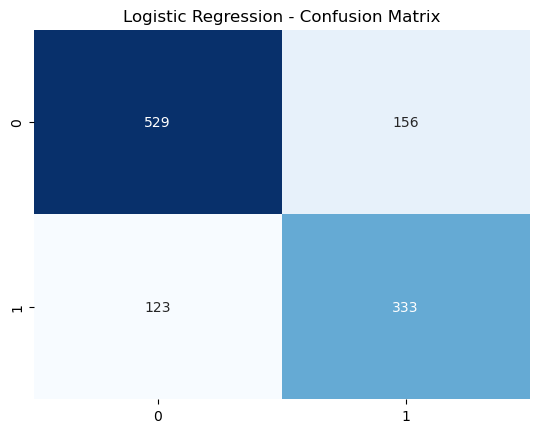

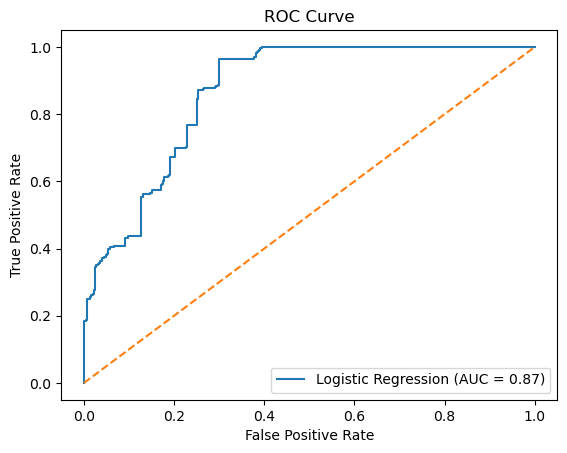

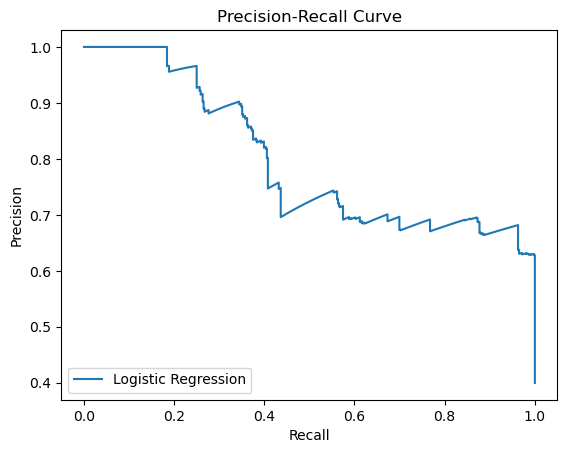


Best params for LinearSVC: {'C': 1}, Best CV Score: 0.7496

LinearSVC - Train Accuracy: 0.7402, Test Accuracy: 0.7292
LinearSVC is well-fitted to the data.
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.75      0.77       685
           1       0.65      0.70      0.67       456

    accuracy                           0.73      1141
   macro avg       0.72      0.72      0.72      1141
weighted avg       0.73      0.73      0.73      1141



D:\Anacnda\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


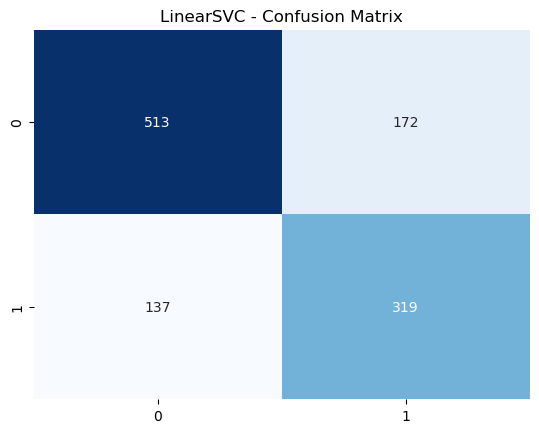

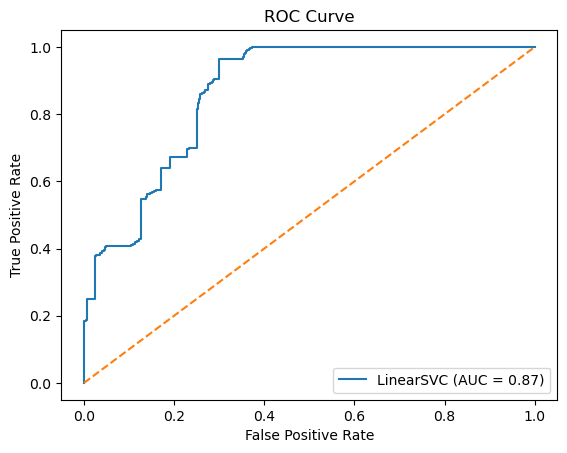

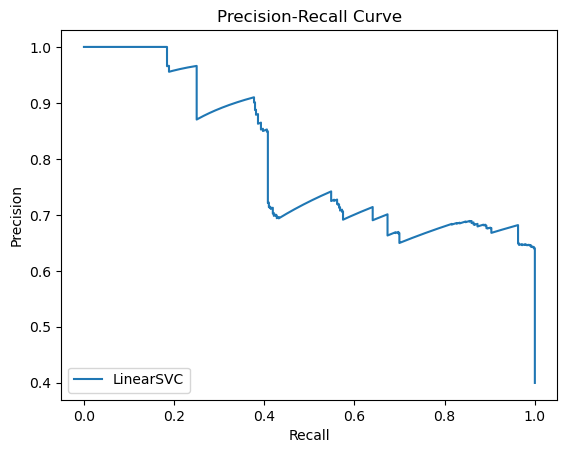


Best params for Decision Tree: {'max_depth': None}, Best CV Score: 0.9865

Decision Tree - Train Accuracy: 1.0000, Test Accuracy: 0.9790
Decision Tree is well-fitted to the data.
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       685
           1       0.97      0.98      0.97       456

    accuracy                           0.98      1141
   macro avg       0.98      0.98      0.98      1141
weighted avg       0.98      0.98      0.98      1141



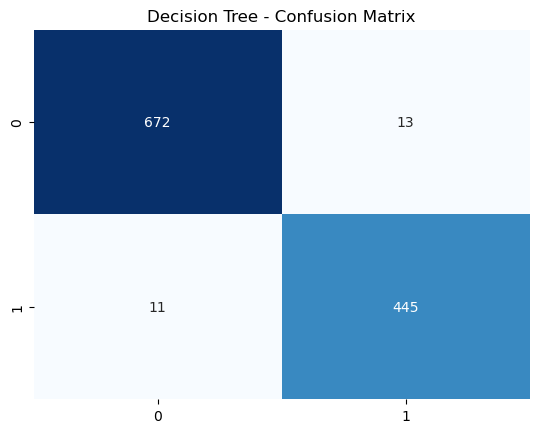

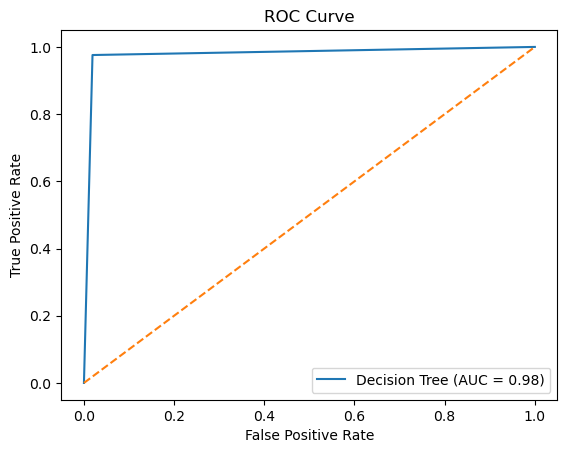

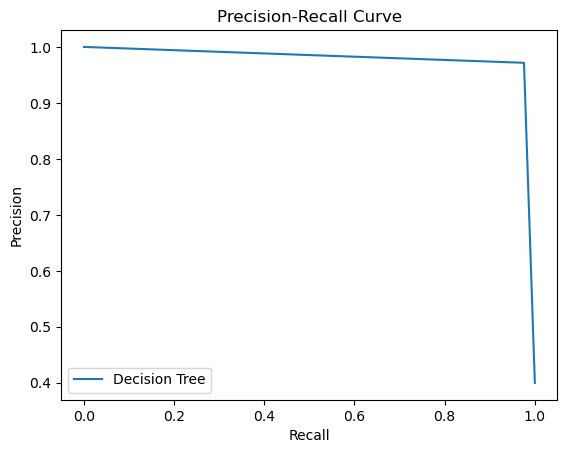

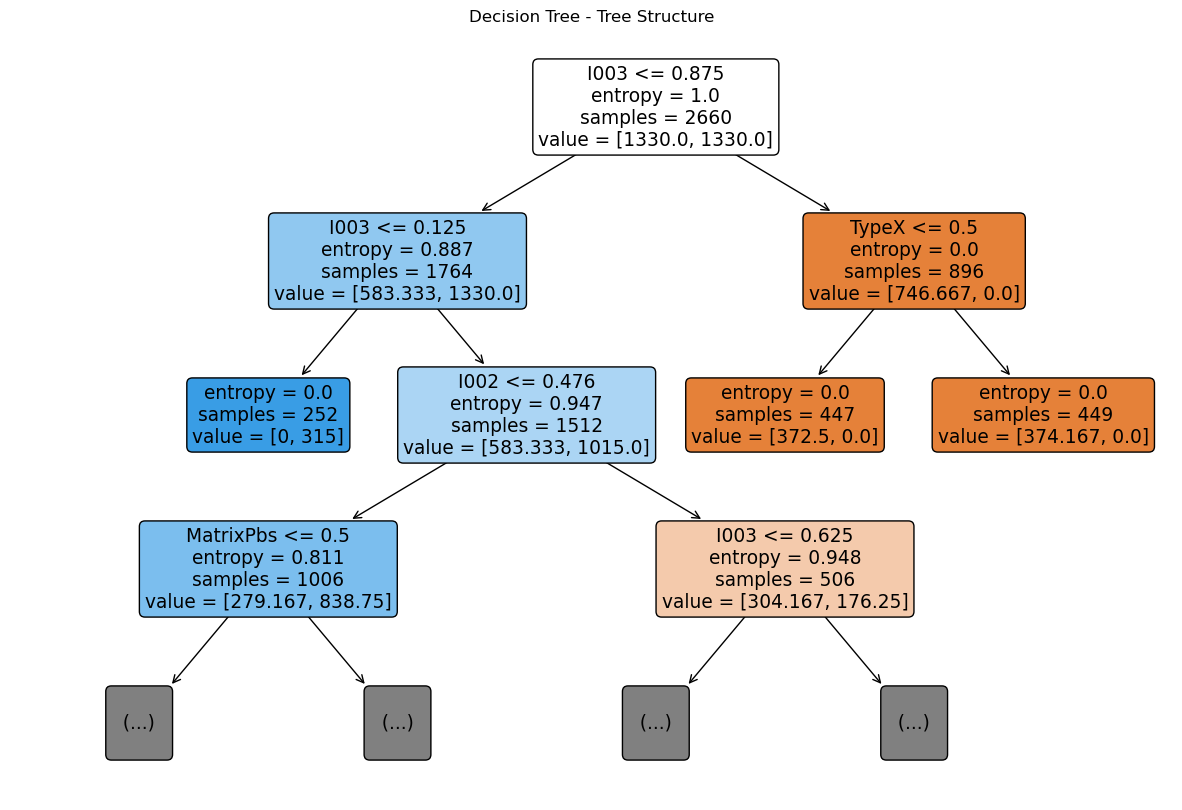


Best params for SGD Classifier: {'alpha': 0.0001}, Best CV Score: 0.7669

SGD Classifier - Train Accuracy: 0.7383, Test Accuracy: 0.7353
SGD Classifier is well-fitted to the data.
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.80      0.78       685
           1       0.68      0.64      0.66       456

    accuracy                           0.74      1141
   macro avg       0.72      0.72      0.72      1141
weighted avg       0.73      0.74      0.73      1141



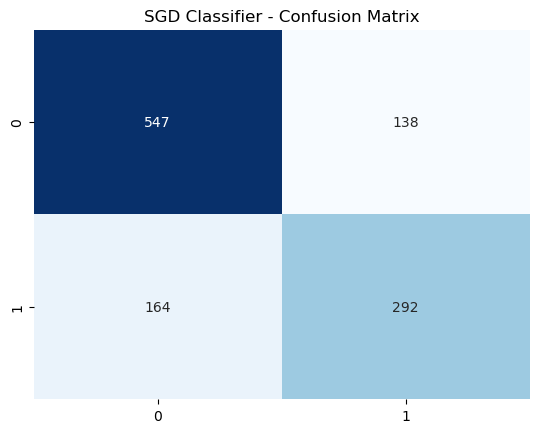

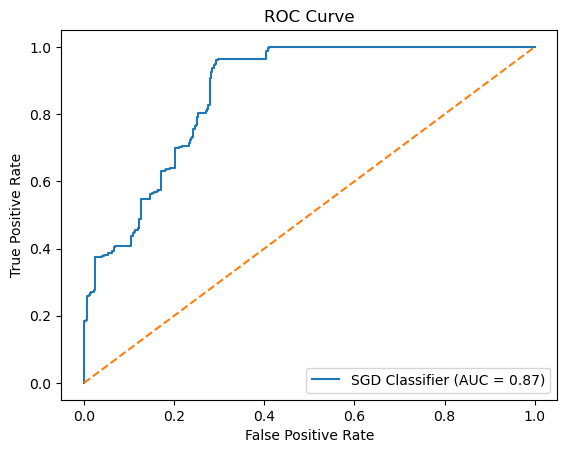

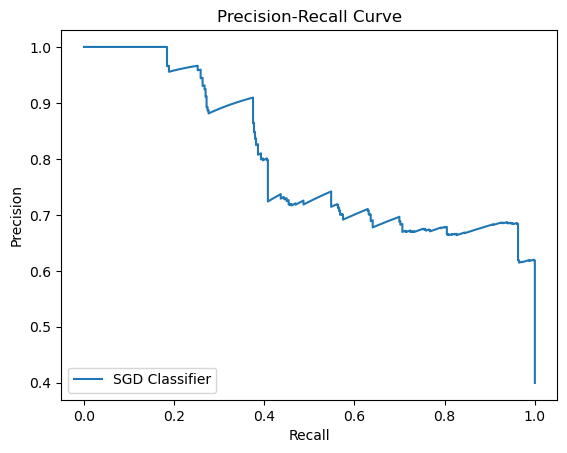


Best params for Bagging Classifier: {'n_estimators': 100}, Best CV Score: 0.9865

Bagging Classifier - Train Accuracy: 1.0000, Test Accuracy: 0.9798
Bagging Classifier is well-fitted to the data.
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       685
           1       0.97      0.98      0.97       456

    accuracy                           0.98      1141
   macro avg       0.98      0.98      0.98      1141
weighted avg       0.98      0.98      0.98      1141



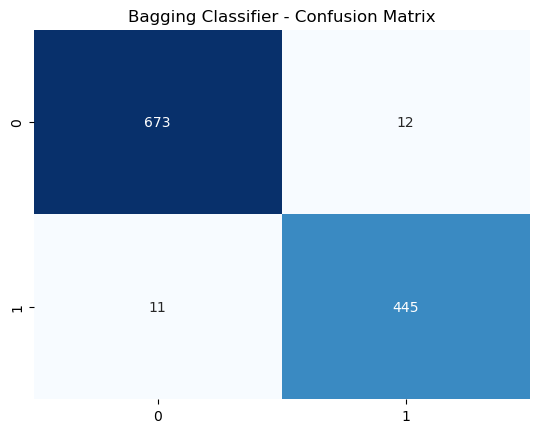

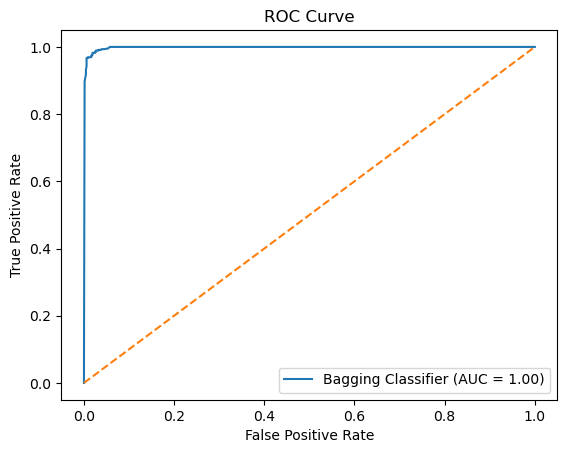

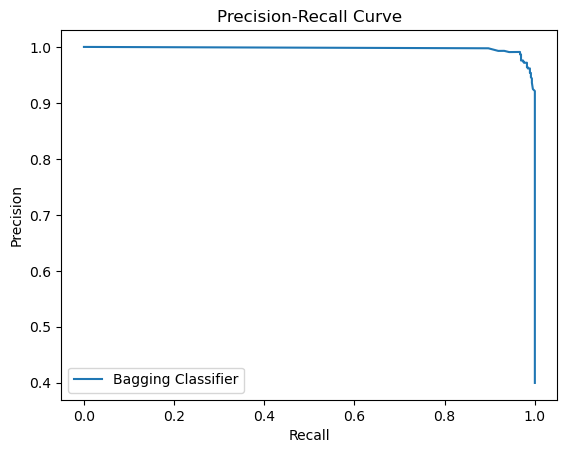


Best params for Random Forest: {'n_estimators': 100}, Best CV Score: 0.9887

Random Forest - Train Accuracy: 1.0000, Test Accuracy: 0.9807
Random Forest is well-fitted to the data.
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       685
           1       0.98      0.98      0.98       456

    accuracy                           0.98      1141
   macro avg       0.98      0.98      0.98      1141
weighted avg       0.98      0.98      0.98      1141



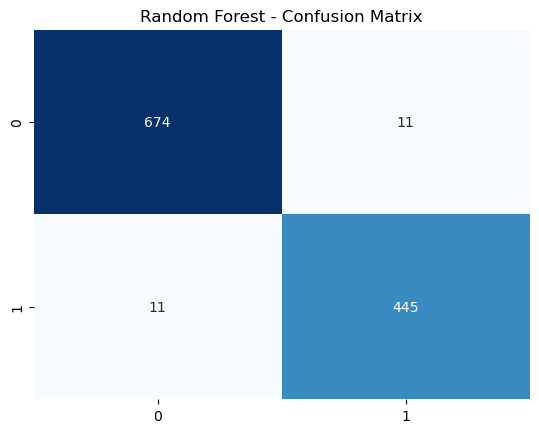

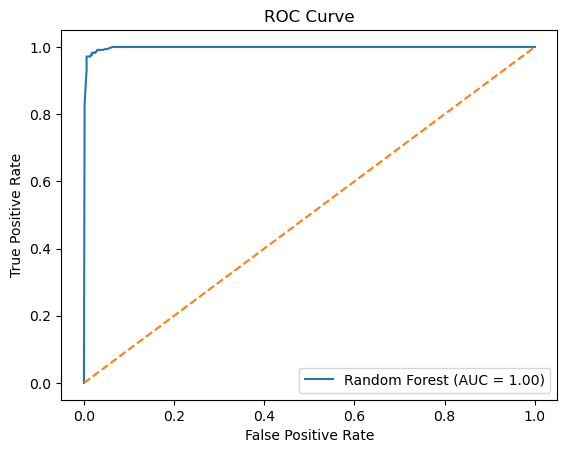

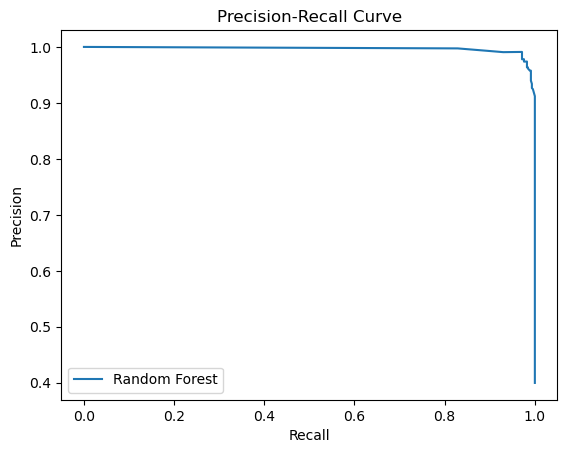


The best model is Random Forest with a test accuracy of 0.9807.


In [609]:

# Define Model List
models = [
    {'name': 'Logistic Regression', 'model': LogisticRegression(max_iter=1000, class_weight='balanced'), 'param_grid': {'C': [0.01, 0.1, 1, 10]}},
    {'name': 'LinearSVC', 'model': LinearSVC(class_weight='balanced'), 'param_grid': {'C': [0.01, 0.1, 1, 10]}},
    {'name': 'Decision Tree', 'model': DecisionTreeClassifier(random_state=42, class_weight='balanced', criterion='entropy'), 'param_grid': {'max_depth': [None, 10, 20]}},
    {'name': 'SGD Classifier', 'model': SGDClassifier(random_state=42, class_weight='balanced'), 'param_grid': {'alpha': [0.0001, 0.001]}},
    {'name': 'Bagging Classifier', 'model': BaggingClassifier(random_state=42), 'param_grid': {'n_estimators': [50, 100]}},
    {'name': 'Random Forest', 'model': RandomForestClassifier(random_state=42, class_weight='balanced'), 'param_grid': {'n_estimators': [100, 200]}}
]

# Cross-Validation
def cross_validate_model(model, X, y, param_grid, k_folds=5):
    cv = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
    grid_search = GridSearchCV(model, param_grid, cv=cv, n_jobs=-1, scoring='accuracy')
    grid_search.fit(X, y)
    return grid_search.best_estimator_, grid_search.best_params_, grid_search.best_score_

# Plot Decision Boundary (for LinearSVC, SGD, Logistic Regression)
def plot_decision_boundary(model, X, y, title):
    plt.figure()
    sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=y, palette="coolwarm")
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 1, X.iloc[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    plt.title(f"{title} Decision Boundary")
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.show()

# Visualize Tree Structure (for Decision Tree, Bagging, Random Forest)
def plot_tree_structure(model, title):
    plt.figure(figsize=(15, 10))
    plot_tree(model, filled=True, rounded=True, feature_names=X_train.columns, max_depth=3)
    plt.title(f"{title} - Tree Structure")
    plt.show()



# Evaluate Model
def evaluate_model(model_name, best_model, X_test, y_test, X_train, y_train):
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)
    
    print(f"\n{model_name} - Train Accuracy: {accuracy_train:.4f}, Test Accuracy: {accuracy_test:.4f}")
    
    # Overfitting/Underfitting Check
    if accuracy_train > accuracy_test + 0.05:
        print(f"{model_name} is likely overfitting.")
    elif accuracy_test > accuracy_train + 0.05:
        print(f"{model_name} is likely underfitting.")
    else:
        print(f"{model_name} is well-fitted to the data.")
    
    # ROC Curve, Precision-Recall, Confusion Matrix, and Residuals
    y_pred_proba = best_model.decision_function(X_test) if not hasattr(best_model, "predict_proba") else best_model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    print("Classification Report:\n", classification_report(y_test, y_pred_test))

    # Confusion Matrix
    sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()
    
    # ROC Curve
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    # Precision-Recall Curve
    plt.plot(recall_vals, precision_vals, label=f'{model_name}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower left')
    plt.show()

    # Decision Boundary (for Logistic, LinearSVC, SGD)
    if model_name in ['Logistic Regression', 'LinearSVC', 'SGD Classifier'] and X_train.shape[1] == 2:
        plot_decision_boundary(best_model, X_train, y_train, model_name)
    
    # Tree Structure (for Decision Tree, Bagging, Random Forest)
    if model_name in ['Decision Tree', 'Bagging Classifier', 'Random Forest'] and hasattr(best_model, 'tree_'):
        plot_tree_structure(best_model, model_name)
    


# Run Cross-Validation, Evaluation, and Identify Best Model
best_model = None
best_test_accuracy = 0
best_model_name = ""
for model_dict in models:
    model_name = model_dict['name']
    best_model_cv, best_params, best_score = cross_validate_model(model_dict['model'], X_train_scaled_df[selected_features], y_train_new, model_dict['param_grid'])
    print(f"\nBest params for {model_name}: {best_params}, Best CV Score: {best_score:.4f}")
    
    evaluate_model(model_name, best_model_cv, X_test_scaled_df[selected_features], y_test_new, X_train_scaled_df[selected_features], y_train_new)
    
    # Track the best model based on test accuracy
    test_accuracy = accuracy_score(y_test_new, best_model_cv.predict(X_test_scaled_df[selected_features]))
    if test_accuracy > best_test_accuracy:
        best_test_accuracy = test_accuracy
        best_model = best_model_cv
        best_model_name = model_name

print(f"\nThe best model is {best_model_name} with a test accuracy of {best_test_accuracy:.4f}.")


## 3. Clustering Approach
Now take the problem as a clustering problem – cluster data and
then predict by the mean of viral loads of a cluster. Again, you need to design and justify
clustering experiments including data preprocessing, feature engineering, model
selection, and evaluation; conduct experiments and analyse results, making full use of
the provided d
ter.

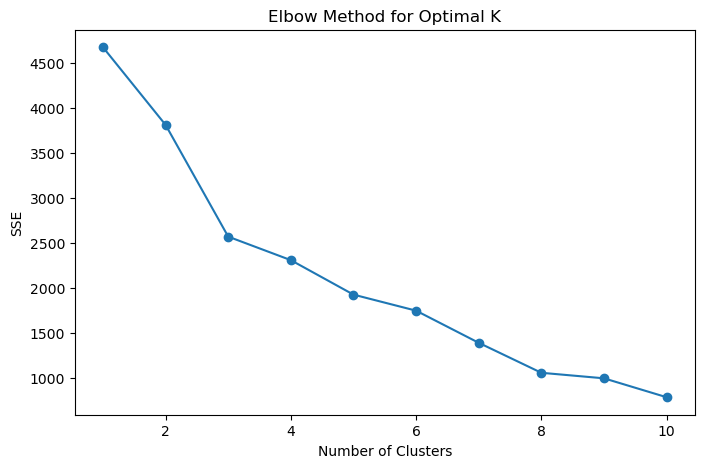

KMeans Silhouette Score: 0.5832156755388093
Agglomerative Silhouette Score: 0.5856759725773012
DBSCAN Silhouette Score: 0.7993236660013116


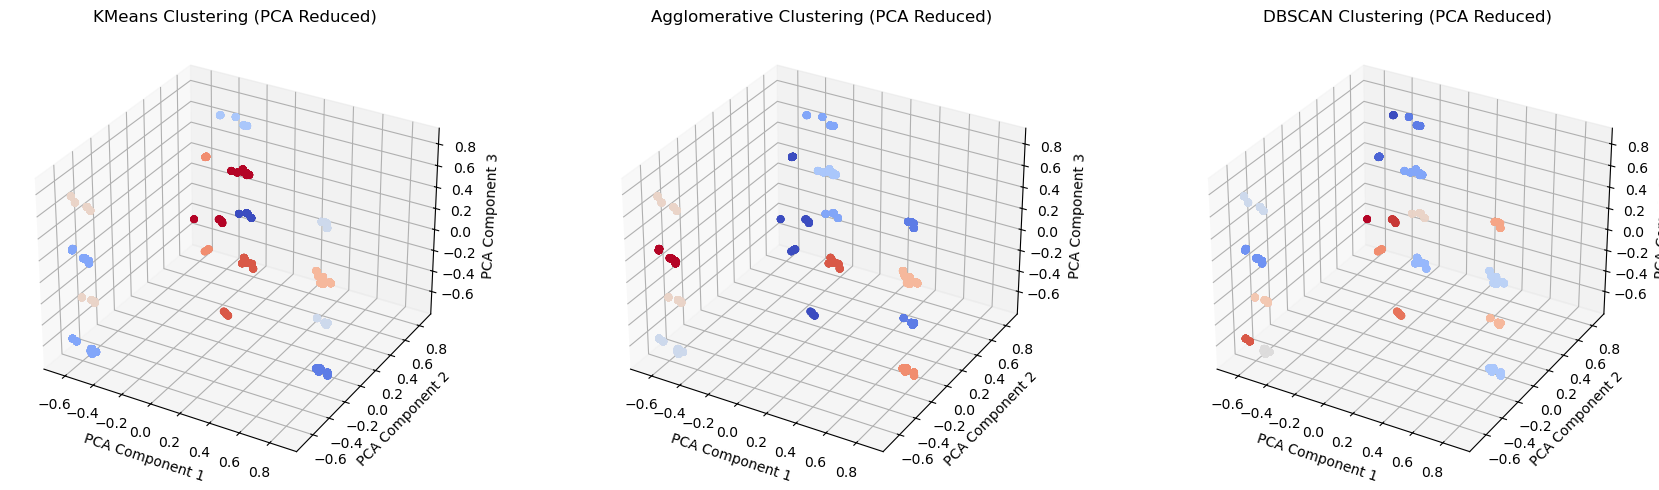

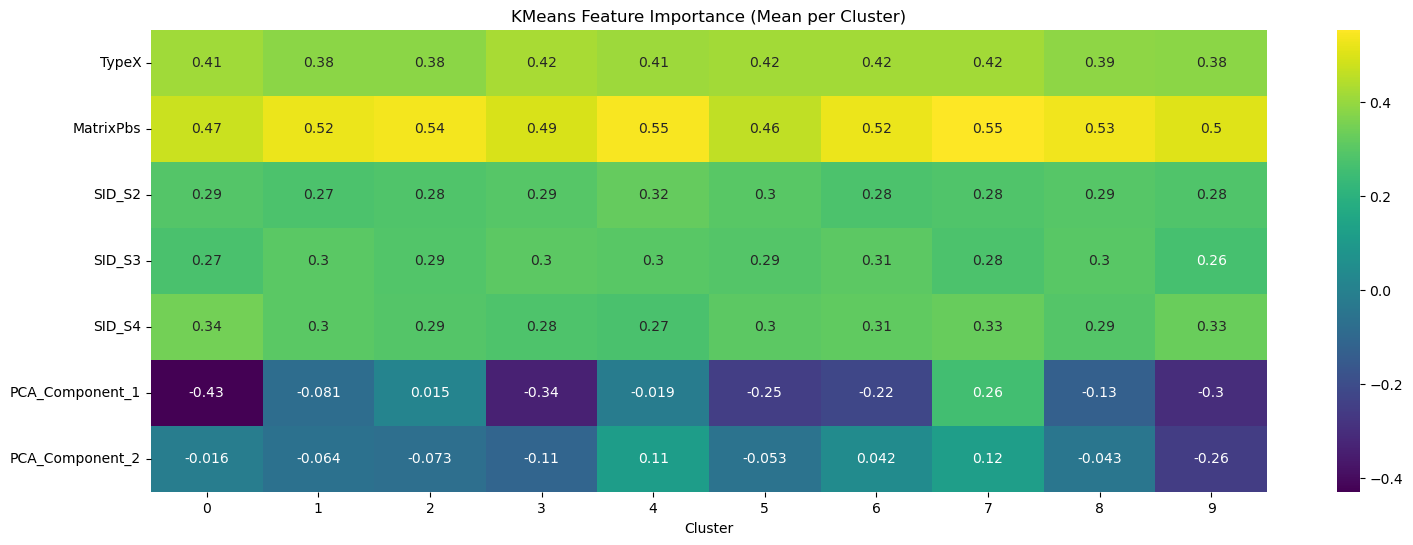

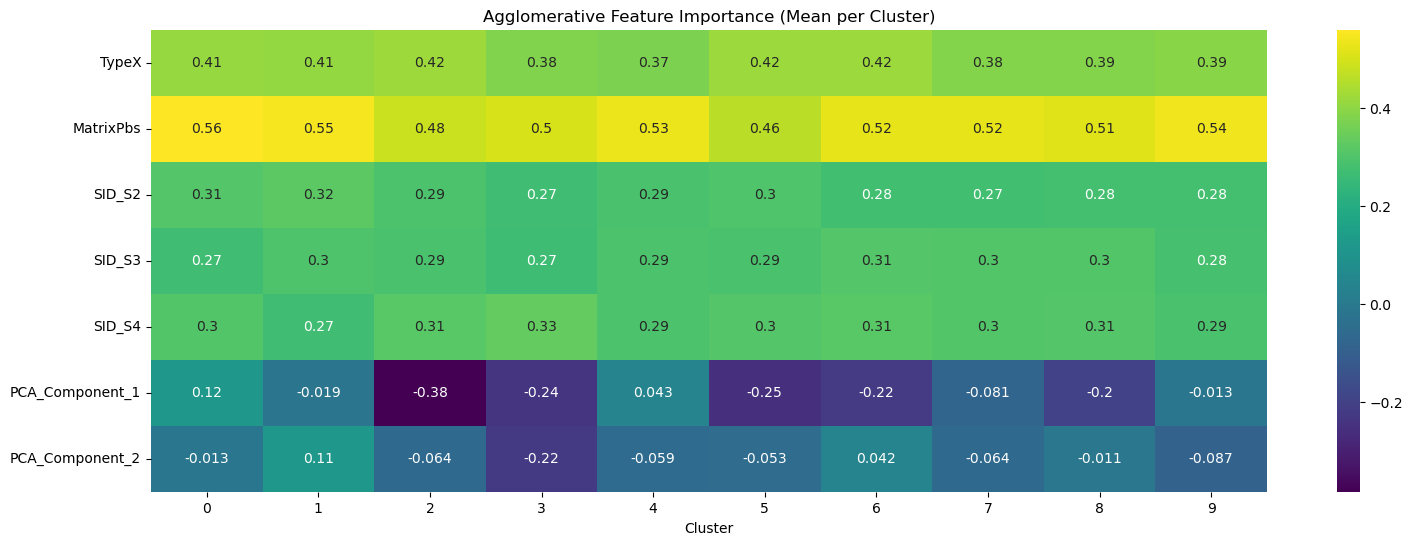

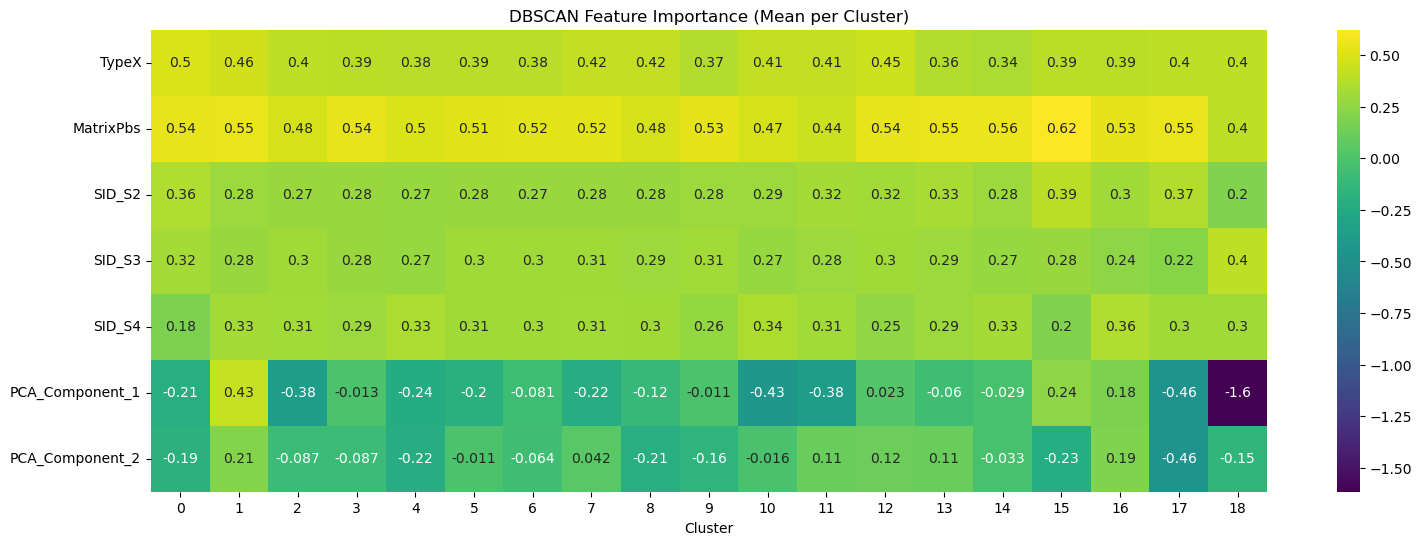

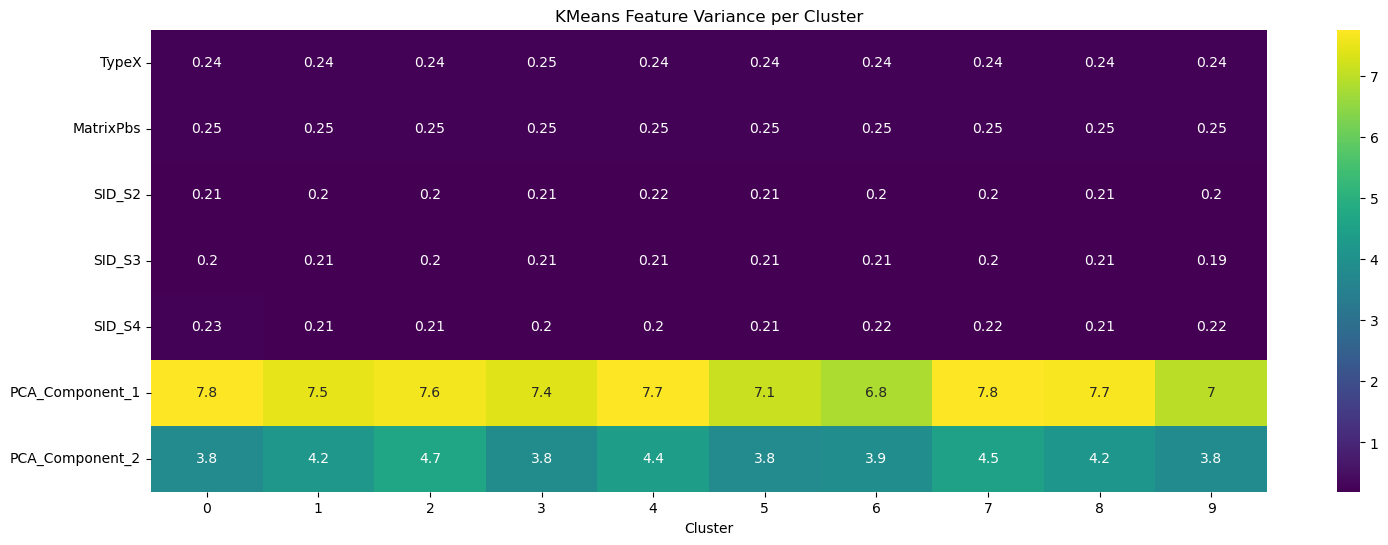

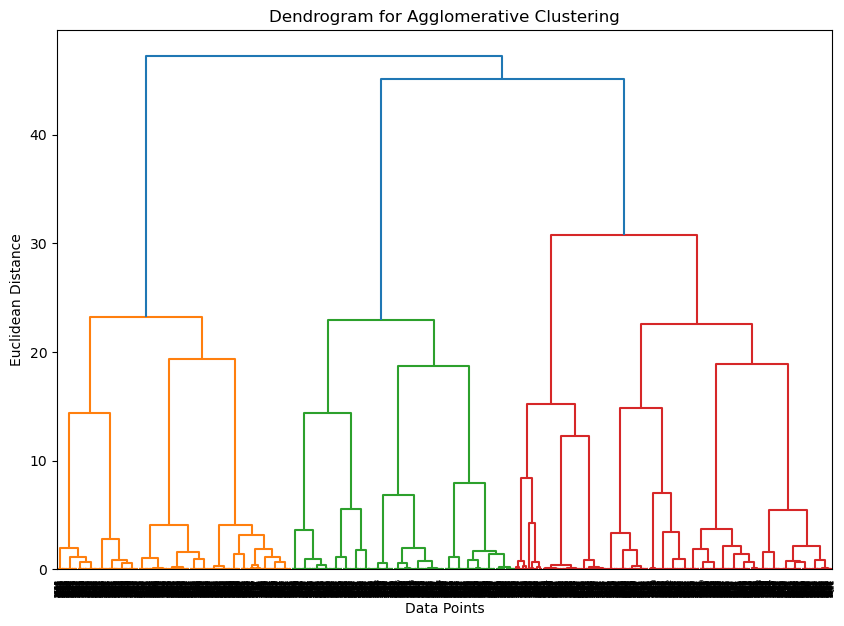

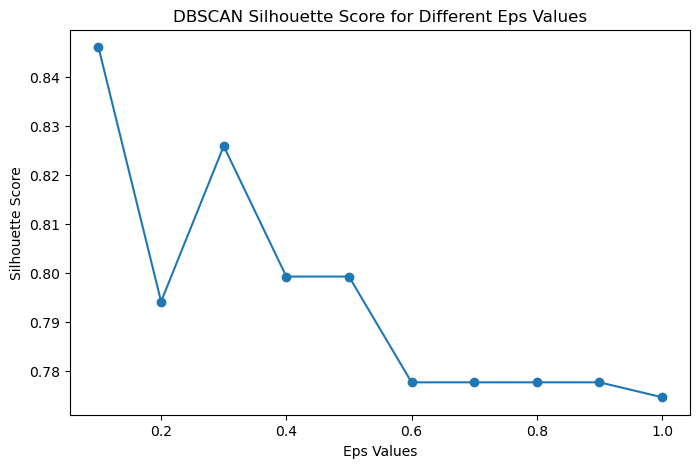

Best K for KMeans: 10 with Silhouette Score: 0.5832156755388093
Best K for Agglomerative: 10 with Silhouette Score: 0.5856759725773012
Best Eps for DBSCAN: 0.1 with Silhouette Score: 0.8461431922624368
Number of clusters identified by DBSCAN (excluding noise): 16
y_all length: 3801
kmeans_predicted length: 3801
agglo_predicted length: 3801
dbscan_predicted length: 3801
KMeans MSE: 2.8416143849966486
Agglomerative MSE: 2.988133738874879
DBSCAN MSE: 2.830167284134316
KMeans Cluster Means:
   Mean Viral Load
0         2.500000
1         5.000000
2         5.000000
3         2.500000
4         2.500000
5         2.500000
6         4.875000
7         2.750000
8         5.065693
9         5.000000

Agglomerative Cluster Means:
   Mean Viral Load
0         3.463415
1         2.500000
2         2.500000
3         5.000000
4         5.000000
5         2.500000
6         4.875000
7         5.000000
8         5.000000
9         5.000000

DBSCAN Cluster Means:
    Mean Viral Load
0          2.5000

C:\Users\imama.jawad\AppData\Local\Temp\ipykernel_37636\542026043.py:255: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=kmeans_labels, y=y_all, palette="viridis")
C:\Users\imama.jawad\AppData\Local\Temp\ipykernel_37636\542026043.py:262: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=agglo_labels, y=y_all, palette="viridis")
C:\Users\imama.jawad\AppData\Local\Temp\ipykernel_37636\542026043.py:269: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=dbscan_labels, y=y_all, palette="viridis")


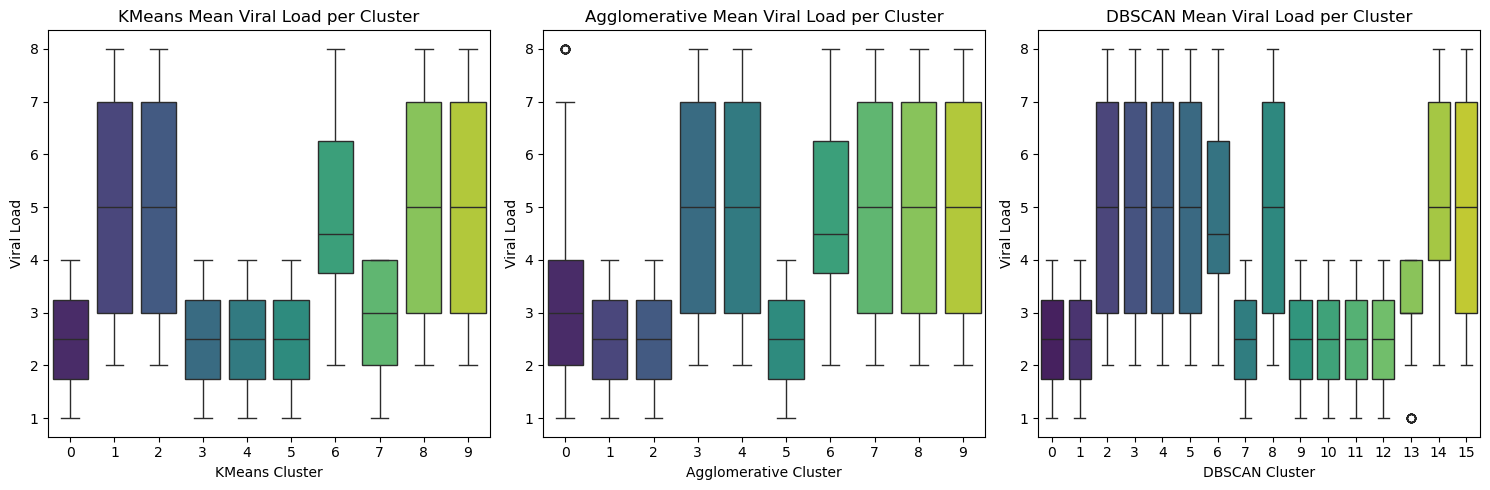

In [1052]:


X_all = pd.concat([X_train_combined, X_val_combined, X_test_combined], axis=0)
y_all = pd.concat([y_train, y_val, y_test], axis=0)
data_all = pd.concat([X_all, y_all], axis=1)

# Scaling the features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_all)  # Scaling the features without the target variable

# Step 2: K-Means Clustering - Finding optimal k using the Elbow method
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.title('Elbow Method for Optimal K')
plt.show()

optimal_k = 10 # Adjust based on elbow plot

# Step 3: Clustering Models
# K-Means Clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=optimal_k)
agglo_labels = agglo.fit_predict(X_scaled)

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Step 4: Evaluate Clustering
print("KMeans Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))
print("Agglomerative Silhouette Score:", silhouette_score(X_scaled, agglo_labels))
dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels) if len(set(dbscan_labels)) > 1 else "N/A"
print("DBSCAN Silhouette Score:", dbscan_silhouette)

# Step 5: Visualize Clusters using PCA
# Step 5: Visualize Clusters using PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)  # Reduce the data to 3D for better visualization

# 3D Visualization of Clusters for KMeans, Agglomerative, DBSCAN
fig = plt.figure(figsize=(18, 5))

# KMeans Cluster Visualization in 3D
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=kmeans_labels, cmap='coolwarm')
ax1.set_title('KMeans Clustering (PCA Reduced)')
ax1.set_xlabel('PCA Component 1')
ax1.set_ylabel('PCA Component 2')
ax1.set_zlabel('PCA Component 3')

# Agglomerative Cluster Visualization in 3D
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=agglo_labels, cmap='coolwarm')
ax2.set_title('Agglomerative Clustering (PCA Reduced)')
ax2.set_xlabel('PCA Component 1')
ax2.set_ylabel('PCA Component 2')
ax2.set_zlabel('PCA Component 3')

# DBSCAN Cluster Visualization in 3D
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=dbscan_labels, cmap='coolwarm')
ax3.set_title('DBSCAN Clustering (PCA Reduced)')
ax3.set_xlabel('PCA Component 1')
ax3.set_ylabel('PCA Component 2')
ax3.set_zlabel('PCA Component 3')

plt.tight_layout()
plt.show()

# Step 6: Feature Importance (Mean and Variance) within Each Cluster
# Function to calculate feature importance (mean and variance)
def feature_importance(cluster_labels, X_all):
    clusters = pd.DataFrame(cluster_labels, columns=['Cluster'])
    features = pd.concat([X_all, clusters], axis=1)
    
    # Mean and variance for each feature per cluster
    feature_means = features.groupby('Cluster').mean()
    feature_variances = features.groupby('Cluster').var()
    
    return feature_means, feature_variances

# KMeans Feature Importance
kmeans_feature_means, kmeans_feature_variances = feature_importance(kmeans_labels, X_all)
# Agglomerative Feature Importance
agglo_feature_means, agglo_feature_variances = feature_importance(agglo_labels, X_all)
# DBSCAN Feature Importance (ignoring noise points labeled as NaN)
dbscan_feature_means, dbscan_feature_variances = feature_importance(dbscan_labels, X_all)

# Visualize Feature Means for KMeans
plt.figure(figsize=(18, 6))
sns.heatmap(kmeans_feature_means.T, cmap='viridis', annot=True)
plt.title('KMeans Feature Importance (Mean per Cluster)')
plt.show()

# Visualize Feature Means for Agglomerative Clustering
plt.figure(figsize=(18, 6))
sns.heatmap(agglo_feature_means.T, cmap='viridis', annot=True)
plt.title('Agglomerative Feature Importance (Mean per Cluster)')
plt.show()

# Visualize Feature Means for DBSCAN
plt.figure(figsize=(18, 6))
sns.heatmap(dbscan_feature_means.T, cmap='viridis', annot=True)
plt.title('DBSCAN Feature Importance (Mean per Cluster)')
plt.show()

# Visualize Feature Variances for KMeans
plt.figure(figsize=(18, 6))
sns.heatmap(kmeans_feature_variances.T, cmap='viridis', annot=True)
plt.title('KMeans Feature Variance per Cluster')
plt.show()



# Step 8: Dendrogram for Agglomerative Clustering
Z = linkage(X_scaled, 'ward')

plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title("Dendrogram for Agglomerative Clustering")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

# Step 9: DBSCAN Evaluation over a range of eps values
eps_values = np.linspace(0.1, 1.0, 10)
dbscan_silhouette_scores = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    
    # Only evaluate if there are more than 1 cluster (excluding noise)
    if len(set(dbscan_labels)) > 1:
        score = silhouette_score(X_scaled, dbscan_labels)
    else:
        score = -1  # Not valid, since DBSCAN found only 1 cluster or noise
    
    dbscan_silhouette_scores.append(score)

# Plot silhouette scores for DBSCAN
plt.figure(figsize=(8, 5))
plt.plot(eps_values, dbscan_silhouette_scores, marker='o')
plt.xlabel('Eps Values')
plt.ylabel('Silhouette Score')
plt.title('DBSCAN Silhouette Score for Different Eps Values')
plt.show()

# Step 10: Best Parameters Log for KMeans, Agglomerative, and DBSCAN

# KMeans best k (this was already determined in Step 2)
best_k = optimal_k  # Use the optimal_k from earlier step

# Agglomerative Clustering best k (this was also determined in Step 2)
agglo_best_k = optimal_k  # Use the optimal_k from earlier step

# DBSCAN with optimal epsilon (based on the silhouette score from earlier)
eps_best = eps_values[np.argmax(dbscan_silhouette_scores)]

# Output the best parameters for each clustering method
print(f"Best K for KMeans: {best_k} with Silhouette Score: {silhouette_score(X_scaled, kmeans_labels)}")
print(f"Best K for Agglomerative: {agglo_best_k} with Silhouette Score: {silhouette_score(X_scaled, agglo_labels)}")
print(f"Best Eps for DBSCAN: {eps_best} with Silhouette Score: {max(dbscan_silhouette_scores)}")

# Print the number of clusters identified by DBSCAN (including noise labeled as -1)
dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)  # Exclude noise points labeled as -1
print(f"Number of clusters identified by DBSCAN (excluding noise): {dbscan_clusters}")


# Step 7: Calculate Mean Viral Load for Each Cluster and Evaluate MSE
def predict_viral_load_by_cluster(cluster_labels, y_actual):
    # Map each cluster to the mean viral load in that cluster
    cluster_to_load_mean = {label: y_actual[cluster_labels == label].mean() for label in np.unique(cluster_labels)}
    
    # Generate predicted viral load based on assigned cluster's mean
    predicted_loads = np.array([cluster_to_load_mean[label] for label in cluster_labels])
    
    return predicted_loads, cluster_to_load_mean

# Calculate predictions and MSE for each clustering model
kmeans_predicted, kmeans_load_means = predict_viral_load_by_cluster(kmeans_labels, y_all)
agglo_predicted, agglo_load_means = predict_viral_load_by_cluster(agglo_labels, y_all)
dbscan_predicted, dbscan_load_means = predict_viral_load_by_cluster(dbscan_labels, y_all)

# Check that predicted arrays match y_all in length before computing MSE
print("y_all length:", len(y_all))
print("kmeans_predicted length:", len(kmeans_predicted))
print("agglo_predicted length:", len(agglo_predicted))
print("dbscan_predicted length:", len(dbscan_predicted))

# Calculate and print MSE for each model
kmeans_mse = mean_squared_error(y_all, kmeans_predicted)
agglo_mse = mean_squared_error(y_all, agglo_predicted)
dbscan_mse = mean_squared_error(y_all, dbscan_predicted)

print(f"KMeans MSE: {kmeans_mse}")
print(f"Agglomerative MSE: {agglo_mse}")
print(f"DBSCAN MSE: {dbscan_mse}")

# Create DataFrame to display mean load per cluster for each model
# Step 7: Calculate Mean Viral Load for Each Cluster and Evaluate MSE
def predict_viral_load_by_cluster(cluster_labels, y_actual):
    # Map each cluster to the mean viral load in that cluster
    cluster_to_load_mean = {label: y_actual[cluster_labels == label].mean() for label in np.unique(cluster_labels)}
    
    # Generate predicted viral load based on assigned cluster's mean
    predicted_loads = np.array([cluster_to_load_mean[label] for label in cluster_labels])
    
    return predicted_loads, cluster_to_load_mean

# Calculate predictions and MSE for each clustering model
kmeans_predicted, kmeans_cluster_means = predict_viral_load_by_cluster(kmeans_labels, y_all)
agglo_predicted, agglo_cluster_means = predict_viral_load_by_cluster(agglo_labels, y_all)
dbscan_predicted, dbscan_cluster_means = predict_viral_load_by_cluster(dbscan_labels, y_all)

# Print mean viral load per cluster for each model
print("KMeans Cluster Means:")
kmeans_means_df = pd.DataFrame.from_dict(kmeans_cluster_means, orient='index', columns=['Mean Viral Load'])
print(kmeans_means_df)

print("\nAgglomerative Cluster Means:")
agglo_means_df = pd.DataFrame.from_dict(agglo_cluster_means, orient='index', columns=['Mean Viral Load'])
print(agglo_means_df)

print("\nDBSCAN Cluster Means:")
dbscan_means_df = pd.DataFrame.from_dict(dbscan_cluster_means, orient='index', columns=['Mean Viral Load'])
print(dbscan_means_df)

# Step 8: Boxplot for Mean Load of Each Cluster by Model
plt.figure(figsize=(15, 5))

# KMeans Boxplot
plt.subplot(1, 3, 1)
sns.boxplot(x=kmeans_labels, y=y_all, palette="viridis")
plt.title("KMeans Mean Viral Load per Cluster")
plt.xlabel("KMeans Cluster")
plt.ylabel("Viral Load")

# Agglomerative Clustering Boxplot
plt.subplot(1, 3, 2)
sns.boxplot(x=agglo_labels, y=y_all, palette="viridis")
plt.title("Agglomerative Mean Viral Load per Cluster")
plt.xlabel("Agglomerative Cluster")
plt.ylabel("Viral Load")

# DBSCAN Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=dbscan_labels, y=y_all, palette="viridis")
plt.title("DBSCAN Mean Viral Load per Cluster")
plt.xlabel("DBSCAN Cluster")
plt.ylabel("Viral Load")

plt.tight_layout()
plt.show()
